In [2]:
import numpy as np
import pandas as pd
from obspy import UTCDateTime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter, MultipleLocator

import seaborn as sns
from scipy.stats import linregress
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import scipy.stats as stats


from tqdm import tqdm

import sys
sys.path.append('../')
from functions.data_processing.read_data import load_label, load_label2
from functions.utils import *

# Combine inversion results

In [200]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import gc

plt.rcParams.update({
    'font.size': 7,             # Set global font size
    'font.family': 'Arial',      # Set global font family
    'legend.fontsize': 6,        # Set legend font size
    'figure.figsize': (5.5, 3.5), # Set figure size in inches
    'axes.formatter.limits': (-3, 6),
    'axes.formatter.use_mathtext': True,
    'font.weight': 'bold',
    'axes.labelweight': 'bold'
})

import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000  # Increase the chunk size limit
mpl.rcParams['path.simplify'] = True
mpl.rcParams['path.simplify_threshold'] = 0.5  # Adjust this value if needed
from obspy.core import UTCDateTime

import sys
sys.path.append("..")
from functions.data_processing.read_data import load_label, load_label2, load_seismic_data_test

In [101]:
test_dir = "../model_test"
mapping = {161 : 1, 172 : 2, 182 : 3, 183 : 4, 196 : 5, 207 : 6, 223 : 7, 232 : 8}
date_mapping = {161 : '2019-06-10', 172 : '2019-06-21', 196 : '2019-07-15',
                207 : '2019-07-26', 223 : '2019-08-11', 232 : '2019-08-20',
                182 : '2019-07-01', 183 : '2019-07-02'}
interval = 15
models = ['LSTM', 'xLSTM']

In [103]:
interval = 15
models = ['xLSTM']
for station in ['ILL11']:
    test_dir = "../model_test"
    test_dir = f"{test_dir}/{station}"
    # for interval in [5, 15, 30]:
    # for year in [2019, 2020, 2022]:
    for year in [2021, 2023]:
        if year == 2019:
            juldays = [161, 171, 172, 182, 183, 184, 196, 207, 223, 232]
        elif year == 2020:
            juldays = [156, 159, 160, 162, 168, 169, 181, 210, 229, 243]
        elif year == 2022:
            juldays = [156, 185]
        elif year == 2021:
            juldays = [131, 136, 141, 142, 156, 173, 175, 187, 194, 197, 219, 262]
        elif year == 2023:
            juldays = [153, 161, 193]
        for julday in juldays:
            for model in models:            
                output_dir = f"{test_dir}/{model}_{interval}/{year}"
                img_dir = f"{output_dir}/img"
                df_dir = f"{output_dir}/df"
                os.makedirs(img_dir, exist_ok=True)
                os.makedirs(df_dir, exist_ok=True)
                df = None
                for model_julday in [161, 172, 182, 183, 196, 207, 223, 232]:
                    if df is None:
                        # print(model_julday)
                        df = pd.read_csv(f"{test_dir}/{model}_{interval}/{year}/{mapping[model_julday]}/df/{julday}.csv")
                        df['Predicted_Output'] = df['Predicted_Output']
                        df.rename(columns={'Predicted_Output': f'Predicted_Output_{mapping[model_julday]}'}, inplace=True)
                    else:
                        # print(model_julday)
                        temp = pd.read_csv(f"{test_dir}/{model}_{interval}/{year}/{mapping[model_julday]}/df/{julday}.csv")
                        assert np.all(df['Timestamps'] == temp['Timestamps'])
                        # pd.concat([df,temp], ignore_index=True, sort=False)
                        # df.merge(temp, on='Timestamps', how='outer', suffixes=('', f'_{model_julday}'))
                        df[f"Predicted_Output_{mapping[model_julday]}"] = temp["Predicted_Output"]
                        del temp
                df['Predicted_Output_Mean'] = df[[f"Predicted_Output_{mapping[j]}" for j in mapping]].mean(axis=1)
                df['Predicted_Output_Std'] = df[[f"Predicted_Output_{mapping[j]}" for j in mapping]].std(axis=1)
                # df['Predicted_Output_Var'] = df[[f"Predicted_Output_{mapping[j]}" for j in mapping]].var(axis=1)
                # df['Predicted_Output_Sem'] = df[[f"Predicted_Output_{mapping[j]}" for j in mapping]].sem(axis=1)
                df['Predicted_Output_Max'] = df[[f"Predicted_Output_{mapping[j]}" for j in mapping]].max(axis=1)
                df['Predicted_Output_Min'] = df[[f"Predicted_Output_{mapping[j]}" for j in mapping]].min(axis=1)

                df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
                df.to_csv(f"{df_dir}/{julday}.csv", index=False)

                times = df['Timestamps'].apply(lambda x: x.matplotlib_date).to_list()

                fig, ax = plt.subplots(2, 1, figsize=(7.5, 5), sharex=True)
                
                st = load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
                ax[0].plot(st[0].times('matplotlib'), st[0].data, color='black', alpha=0.4, linewidth=0.5)
                ax[0].set_ylabel('Seismic Amplitude');
                if station == "ILL11":
                    ax[0].set_ylim(-1.5, 1.5);
                    ax[1].set_ylim(0, 45)
                elif station == "ILL12":
                    ax[0].set_ylim(-0.5, 0.5);
                    ax[1].set_ylim(0, 20)
                # ax_twin = ax.twinx()
                ax[1].plot(times, df['Predicted_Output_Mean'], label='Mean Prediction', color='black', linewidth=0.5)
                ax[1].fill_between(times, 
                                df['Predicted_Output_Mean'] - df['Predicted_Output_Std'], 
                                df['Predicted_Output_Mean'] + df['Predicted_Output_Std'], 
                                alpha=0.2, label='Standard Deviation', color='red')
                ax[1].fill_between(times, 
                                df['Predicted_Output_Min'], 
                                df['Predicted_Output_Max'], 
                                alpha=0.3, label='Min-Max', color='blue')
                del df
                if year == 2019 and station == 'ILL11':
                    try:
                        data = load_label2([date_mapping[julday]], station='ILL11', interval_seconds=interval, time_shift_minutes="average", smoothing=None, divide_by=None)
                        data['Timestamp'] = data['Timestamp'].apply(lambda x: UTCDateTime(x).matplotlib_date)
                        ax[1].plot(data['Timestamp'].to_numpy(), data['Fv [kN]'], label='Ground Truth', color='green', linewidth=0.8, alpha=0.7)
                        del data
                    except Exception as e:
                        print(f"Error loading ground truth data for : {e}")

                ax[1].set_xlim(times[0], times[-1])
                # ax[1].set_ylim(0, 50)
                ax[1].set_ylabel('Predicted Impact Force (kN)')
                ax[1].set_xlabel('Time')

                for axis in ax:
                    axis.xaxis_date()
                    axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M:%S'))
                    # axis.legend()
                    axis.grid(True, linestyle='--', alpha=0.7)
                fig.tight_layout()
                fig.savefig(f"{img_dir}/{julday}.png", dpi=300, bbox_inches='tight')
                plt.close(fig)
                plt.clf()
                plt.close('all')
                del st, fig, ax, times
                gc.collect()  # Flush RAM after each loop
                # print(f"Saved plot for {model} on {julday} to {img_dir}/{julday}.png")
                print(f"Saved DataFrame for {model} on {julday} to {df_dir}/{julday}.csv")
                print(f"RAM usage = {get_memory_usage_in_gb():.2f} GB")
            gc.collect()  # Flush RAM after each loop
        gc.collect()  # Flush RAM after each loop
        gc.collect()  # Flush RAM after each loop

Saved DataFrame for xLSTM on 131 to ../model_test/ILL11/xLSTM_15/2021/df/131.csv
RAM usage = 1.37 GB
Saved DataFrame for xLSTM on 136 to ../model_test/ILL11/xLSTM_15/2021/df/136.csv
RAM usage = 1.91 GB
Saved DataFrame for xLSTM on 141 to ../model_test/ILL11/xLSTM_15/2021/df/141.csv
RAM usage = 2.44 GB
Saved DataFrame for xLSTM on 142 to ../model_test/ILL11/xLSTM_15/2021/df/142.csv
RAM usage = 2.97 GB
Saved DataFrame for xLSTM on 156 to ../model_test/ILL11/xLSTM_15/2021/df/156.csv
RAM usage = 3.56 GB
Saved DataFrame for xLSTM on 173 to ../model_test/ILL11/xLSTM_15/2021/df/173.csv
RAM usage = 4.16 GB
Saved DataFrame for xLSTM on 175 to ../model_test/ILL11/xLSTM_15/2021/df/175.csv
RAM usage = 4.75 GB
Saved DataFrame for xLSTM on 187 to ../model_test/ILL11/xLSTM_15/2021/df/187.csv
RAM usage = 5.34 GB
Saved DataFrame for xLSTM on 194 to ../model_test/ILL11/xLSTM_15/2021/df/194.csv
RAM usage = 5.94 GB
Saved DataFrame for xLSTM on 197 to ../model_test/ILL11/xLSTM_15/2021/df/197.csv
RAM usage 

# Volume Relation with Impact Force

In [3]:
import json
with open("../config/event_id_map.json", "r") as f:
    event_id_map = json.load(f)

In [12]:
volume_df = pd.read_csv("../label/DF_Characteristics_2019-2023.csv", index_col=0)
volume_df.drop(1, inplace=True)
volume_df.reset_index(drop=True, inplace=True)
volume_df['Event_Date'] = volume_df['Event_Date'].apply(lambda x: UTCDateTime(x))
volume_df.dropna(axis=0, subset=['Volume'], inplace=True)
volume_df.tail()


,Event_Date,Year,Julday,Volume,Velocity,Duration,Density
36,2023-06-02T00:00:00.000000Z,2023,153,4873.0,1.73,NaN,1724
37,2023-06-10T00:00:00.000000Z,2023,161,18534.0,2.02,NaN,1787
38,2023-07-12T00:00:00.000000Z,2023,193,119088.0,15.46,NaN,1785
39,2023-07-13T00:00:00.000000Z,2023,194,301099.0,10.70,NaN,1342
40,2023-11-14T00:00:00.000000Z,2023,318,103808.0,8.28,NaN,1514


In [13]:
volume_df_2019 = volume_df[volume_df['Year'] == 2019]
volume_df_2019['Event_ID'] = [1, 3, 4, 5, 6, 7, 8, 9]
volume_2019 = volume_df_2019['Volume'].to_list()
print(volume_2019)

volume_df_2020 = volume_df[volume_df['Year'] == 2020]
volume_2020 = []
for idx, row in volume_df_2020.iterrows():
    if row['Julday'] in [156, 160, 169, 181, 243]:
        volume_2020.append(row['Volume'])
print(volume_2020)

volume_df_2021 = volume_df[volume_df['Year'] == 2021]
volume_2021 = []
for idx, row in volume_df_2021.iterrows():
    if row['Julday'] in [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]:
        volume_2021.append(row['Volume'])
print(volume_2021)

volume_df_2022 = volume_df[volume_df['Year'] == 2022]
volume_2022 = []
for idx, row in volume_df_2022.iterrows():
    if row['Julday'] in [156, 185]:
        volume_2022.append(row['Volume'])
print(volume_2022)

volume_df_2023 = volume_df[volume_df['Year'] == 2023]
volume_2023 = []
for idx, row in volume_df_2023.iterrows():
    if row['Julday'] in [153, 161, 193]:
        volume_2023.append(row['Volume'])
print(volume_2023)

[2313.0, 83123.0, 73144.0, 4959.0, 9869.0, 29077.0, 70705.0, 21031.0]
[92424.0, 5872.0, 5053.0, 6612.0, 95823.0]
[17741.0, 18972.0, 18044.0, 6127.0, 6175.0, 114424.0, 76906.0, 50861.0, 80880.0, 38737.0, 8538.0]
[39498.0, 115963.0]
[4873.0, 18534.0, 119088.0]


/var/folders/9b/f10dy2654w79wqw49pdgt37c0000gp/T/ipykernel_2377/2314548047.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volume_df_2019['Event_ID'] = [1, 3, 4, 5, 6, 7, 8, 9]


In [52]:
# plt.figure(figsize=(6, 5))
# x_bins = np.linspace(0, 120_000, 10)
# y_bins = np.linspace(0, 9, 9)
# plt.hist2d(volume_df['Volume'], volume_df['Velocity'], bins=[x_bins, y_bins], cmap='viridis')
# plt.colorbar(label='Counts')
# plt.xlabel('Volume (m³)')
# plt.ylabel('Velocity (m/s)')
# plt.title('2D Histogram of Volume vs Velocity')
# plt.tight_layout()
# plt.show()

In [14]:
interval_seconds = 15
thres = 3

In [15]:
volume_2019 = []
csum_list = []
julday_list_2019 = []
for idx, row in tqdm(volume_df_2019.iterrows(), total=len(volume_df_2019)):
    event_info = event_id_map[str(row['Event_ID'])]
    label = load_label([str(row['Event_ID'])], "ILL11", interval_seconds, "average", True, 60, divide_by=None)
    label = label[label['Fv [kN]'] > thres]
    csum = label['Fv [kN]'].sum()
    csum_list.append(np.round(csum))
    volume_2019.append(row['Volume'])
    julday_list_2019.append(f"{row['Julday']}-{str(row['Year'])[-2:]}")

100%|██████████| 8/8 [00:51<00:00,  6.44s/it]


In [16]:
# fig, ax = plt.subplots(1, 1, figsize=(5.5, 5.5))

# ax.plot(csum_list, volume_2019, 'ro')
# ax.plot([csum_list[i] for i in [1, 4, 5, 6, 7]], [83_123, 9_869, 29_077, 70_705, 21_031], 'b*')
# for csum, vol, julday in zip(csum_list, volume_2019, julday_list_2019):
#     ax.text(csum-500, vol+100, julday, fontdict={"size": 8, "weight": "bold"})

# # Regression Line
# filt_csum, filt_vol = [], []
# for csum, vol, julday in zip(csum_list, volume_2019, julday_list_2019):
#     if julday in ["172-19", "196-19", "207-19", "223-19", "232-19"]:
#         filt_csum.append(csum)
#         filt_vol.append(vol)

# # target_slope, target_intercept, _, _, _ = linregress([csum_list[i] for i in [1, 4, 5, 6, 7]], [83_123, 9_869, 29_077, 70_705, 21_031])
# # print(f"Target Line of Best Fit: Slope = {target_slope:.4f}, Intercept = {target_intercept:.4f}")
# # plot_x = np.linspace(0, 15_000, 50)
# # ax.plot(plot_x, target_slope * plot_x + target_intercept, label = f"Slope : {target_slope:.2f}")

# # target_slope, target_intercept, _, _, _ = linregress(csum_list, volume_2019)
# # print(f"Target Line of Best Fit: Slope = {target_slope:.4f}, Intercept = {target_intercept:.4f}")
# # plot_x = np.linspace(0, 15_000, 50)
# # ax.plot(plot_x, target_slope * plot_x + target_intercept, label = f"Slope : {target_slope:.2f}")

# target_slope, target_intercept, _, _, _ = linregress(filt_csum, filt_vol)
# print(f"Target Line of Best Fit: Slope = {target_slope:.4f}, Intercept = {target_intercept:.4f}")
# plot_x = np.linspace(0, 18_000, 50)
# ax.plot(plot_x, target_slope * plot_x + target_intercept, label = f"Slope : {target_slope:.2f}")

# csum_estimate = [target_slope * csum + target_intercept for csum in csum_list]
# ax.plot(csum_list, csum_estimate, 'g*')

# ax.set_xlim(0, 18_000);
# ax.set_ylim(0, 120_000);

# y_val = 25_000
# ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
# ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')
# y_val = 90_000
# ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
# ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')

# ax.set_xlabel('Cumulative Impact Force (kN)')
# ax.set_ylabel('Volume (m³)')
# ax.set_title(f"Threshold > {thres} kN")

In [17]:
test_dir = "../model_test"

In [18]:
interval = interval_seconds
year = 2019
juldays = [161, 172, 182, 183, 196, 207, 223, 232]
event_ids = ["1", "3", "4", "5", "6", "7", "8", "9"]
results_2019 = {}
julday_list_2019 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
for model in ['xLSTM', 'LSTM']:
    prediction_csums = []
    for julday, event_id in tqdm(zip(juldays, event_ids), total=len(juldays)):
        if julday in [182, 183]:
            df1 = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
            df2 = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday+1}.csv", index_col=False)
            df = pd.concat([df1, df2], ignore_index=True)
        else:
            df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(event_id_map[event_id]['start_time']), UTCDateTime(event_id_map[event_id]['end_time']))]
        df.reset_index(drop=True, inplace=True)
        label = load_label([event_id], "ILL11", interval_seconds, "average", True, 60, divide_by=None)
        label['Timestamp'] = label['Timestamp'].apply(lambda x: UTCDateTime(x))
        combined = df.merge(label, how='left', left_on='Timestamps', right_on='Timestamp')
        combined.drop(columns=['Timestamp'], inplace=True)
        temp = combined[combined['Fv [kN]'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
    prediction_csums = np.array(prediction_csums)
    results_2019[model] = prediction_csums

100%|██████████| 8/8 [00:51<00:00,  6.43s/it]


In [19]:
interval = interval_seconds
year = 2020
juldays = [156, 160, 169, 181, 243]
start_times = ["2020-06-04 15:00:00", "2020-06-08 15:00:00", "2020-06-17 03:00:00", "2020-06-29 04:30:00", "2020-08-30 05:00:00"] # "2020-06-07 09:00:00"
end_times = ["2020-06-04 18:00:00", "2020-06-08 21:00:00", "2020-06-17 07:00:00", "2020-06-29 07:30:00", "2020-08-30 12:00:00"] # "2020-06-07 10:30:00"
julday_list_2020 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2020 = {}
for model in ['xLSTM']:
    prediction_csums = []
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
    prediction_csums = np.array(prediction_csums)
    results_2020[model] = prediction_csums

100%|██████████| 5/5 [00:00<00:00,  5.63it/s]


In [20]:
interval = interval_seconds
year = 2021
juldays = [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]
start_times = ["2021-05-11 13:30:00", "2021-05-16 15:30:00", "2021-05-21 22:00:00", "2021-06-05 09:00:00",
            "2021-06-22 19:00:00", "2021-06-24 14:30:00", "2021-07-06 18:00:00", "2021-07-13 15:00:00",
            "2021-07-16 03:00:00", "2021-08-07 13:30:00", "2021-09-19 05:30:00"]
end_times = ["2021-05-11 19:30:00", "2021-05-16 22:00:00", "2021-05-22 02:30:00", "2021-06-05 13:00:00",
            "2021-06-22 22:30:00", "2021-06-24 19:00:00", "2021-07-06 22:00:00", "2021-07-13 20:00:00",
            "2021-07-16 08:00:00", "2021-08-07 18:00:00", "2021-09-19 12:30:00"]
julday_list_2021 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2021 = {}
for model in ['xLSTM']:
    prediction_csums = []
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        if julday == 142:
            df1 = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday-1}.csv", index_col=False)
            df2 = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
            df = pd.concat([df1, df2], ignore_index=True)
        else:
            df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
    prediction_csums = np.array(prediction_csums)
    results_2021[model] = prediction_csums

100%|██████████| 11/11 [00:02<00:00,  4.28it/s]


In [21]:
interval = interval_seconds
year = 2022
juldays = [156, 185]
start_times = ["2022-06-05 10:30:00", "2022-07-04 21:00:00"]
end_times = ["2022-06-05 13:30:00", "2022-07-04 23:59:59"]
julday_list_2022 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2022 = {}
for model in ['xLSTM', 'LSTM']:
    prediction_csums = []
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
    prediction_csums = np.array(prediction_csums)
    results_2022[model] = prediction_csums

100%|██████████| 2/2 [00:00<00:00,  5.86it/s]


In [22]:
interval = interval_seconds
year = 2023
juldays = [153, 161, 193]
start_times = ["2023-06-02 17:00:00", "2023-06-10 05:00:00", "2023-07-12 03:00:00"]
end_times = ["2023-06-02 21:30:00", "2023-06-10 09:30:00", "2023-07-12 06:00:00"]
julday_list_2023 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2023 = {}
for model in ['xLSTM']:
    prediction_csums = []
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
    prediction_csums = np.array(prediction_csums)
    results_2023[model] = prediction_csums

100%|██████████| 3/3 [00:00<00:00,  5.70it/s]


Target Line of Best Fit: Slope = 20.7080, Intercept = -19174.0396
Target Line of Best Fit: Slope = 20.7080, Intercept = -19174.0396


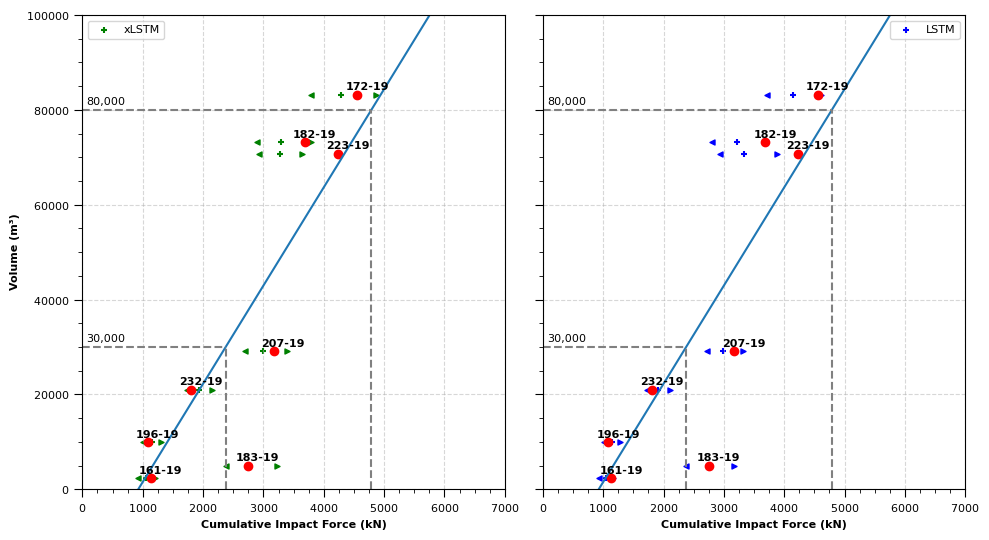

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5.5), sharey=True)

if interval_seconds == 5:
    xlim = 20_000
    xlim_major = 2_500
    xlim_minor = 500
elif interval_seconds == 15:
    xlim = 7_000
    xlim_major = 1_000
    xlim_minor = 250

for axis in axes:
    axis.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    axis.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    axis.xaxis.set_minor_locator(MultipleLocator(xlim_minor))
    axis.xaxis.set_major_locator(MultipleLocator(xlim_major))
    axis.yaxis.set_major_locator(MultipleLocator(20000))
    axis.yaxis.set_minor_locator(MultipleLocator(5000))
    axis.tick_params(axis='both', which='major', labelsize=8, length=6)
    axis.tick_params(axis='both', which='minor', labelsize=7, length=3)
    axis.set_xticks(range(0, xlim + 1, xlim_major))
    axis.set_yticks(range(0, 100_000 + 1, 20000))
    axis.set_ylim(0, 100_000)
    axis.set_xlim(0, xlim);
    axis.set_xlabel('Cumulative Impact Force (kN)', fontsize=8, fontweight="bold")
    if axis == axes[0]:
        axis.set_ylabel('Volume (m³)', fontsize=8, fontweight="bold")

for ax in axes:
    ax.plot(csum_list, volume_2019, 'ro')
    for csum, vol, julday in zip(csum_list, volume_2019, julday_list_2019):
        ax.text(csum-200, vol+1000, julday, fontdict={"size": 8, "weight": "bold"})

    # Regression Line
    filt_csum, filt_vol = [], []
    for csum, vol, julday in zip(csum_list, volume_2019, julday_list_2019):
        if julday in ["161-19", "172-19", "196-19", "207-19", "223-19", "232-19"]: # Data with new volumes
            filt_csum.append(csum)
            filt_vol.append(vol)

    target_slope, target_intercept, _, _, _ = linregress(filt_csum, filt_vol)
    print(f"Target Line of Best Fit: Slope = {target_slope:.4f}, Intercept = {target_intercept:.4f}")
    plot_x = np.linspace(0, xlim, 50)
    ax.plot(plot_x, target_slope * plot_x + target_intercept)

    ax.set_xlim(0, xlim);
    ax.set_ylim(0, 100_000);

    y_val = 30_000
    ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
    ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')
    y_val = 80_000
    ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
    ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')

    ax.set_xlabel('Cumulative Impact Force (kN)')
    if ax == axes[0]:
        ax.set_ylabel('Volume (m³)')


for i, model in enumerate(['xLSTM', 'LSTM']):
    color = "green" if model == 'xLSTM' else "blue"
    axes[i].scatter(results_2019[model][:,0], volume_2019, color=color, marker="+", s=15, label=f"{model}")
    axes[i].scatter(results_2019[model][:,1], volume_2019, color=color, marker="<", s=13)
    axes[i].scatter(results_2019[model][:,2], volume_2019, color=color, marker=">", s=13)

for axis in axes:
    axis.legend(loc="best", fontsize=8)
    axis.grid(True, linestyle="--", alpha=0.5)
    axis.text(0.01, 31_000/100_000, "30,000", transform=axis.transAxes, fontsize=8)
    axis.text(0.01, 81_000/100_000, "80,000", transform=axis.transAxes, fontsize=8)
fig.tight_layout()
# fig.savefig(f"./output_images2/vol-force-selftest-thres{thres}_{interval_seconds}.png", dpi=300)

In [14]:
# fig, axes = plt.subplots(1, 2, figsize=(10, 5.5), sharey=True)

# for axis in axes:
#     axis.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#     axis.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#     axis.xaxis.set_minor_locator(MultipleLocator(750))
#     axis.xaxis.set_major_locator(MultipleLocator(3_000))
#     axis.yaxis.set_major_locator(MultipleLocator(20_000))
#     axis.yaxis.set_minor_locator(MultipleLocator(5_000))
#     axis.tick_params(axis='both', which='major', labelsize=8, length=6)
#     axis.tick_params(axis='both', which='minor', labelsize=7, length=3)
#     axis.set_xticks(range(0, 20_000 + 1, 3_000))
#     axis.set_yticks(range(0, 120_000 + 1, 20000))
#     axis.set_ylim(0, 120_000)
#     axis.set_xlim(0, 20_000);
#     axis.set_xlabel('Cumulative Impact Force (kN)', fontsize=8, fontweight="bold")
#     if axis == axes[0]:
#         axis.set_ylabel('Volume (m³)', fontsize=8, fontweight="bold")

# for ax in axes:
#     ax.plot(csum_list, volume_2019, 'ro', alpha=0.3)

#     # Regression Line
#     filt_csum, filt_vol = [], []
#     for csum, vol, julday in zip(csum_list, volume_2019, julday_list_2019):
#         if julday in ["172-19", "196-19", "207-19", "223-19", "232-19"]: # Data with new volumes
#             filt_csum.append(csum)
#             filt_vol.append(vol)

#     target_slope, target_intercept, _, _, _ = linregress(filt_csum, filt_vol)
#     print(f"Target Line of Best Fit: Slope = {target_slope:.4f}, Intercept = {target_intercept:.4f}")
#     plot_x = np.linspace(0, 20_000, 50)
#     ax.plot(plot_x, target_slope * plot_x + target_intercept)

#     # csum_estimate = [target_slope * csum + target_intercept for csum in csum_list]
#     # ax.plot(csum_list, csum_estimate, 'k*', markersize=3)

#     ax.set_xlim(0, 20_000);
#     ax.set_ylim(0, 120_000);

#     y_val = 30_000
#     ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
#     ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')
#     y_val = 80_000
#     ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
#     ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')

#     ax.set_xlabel('Cumulative Impact Force (kN)')
#     if ax == axes[0]:
#         ax.set_ylabel('Volume (m³)')

# # axes[0].plot(results_2020['xLSTM'][:,0], volume_2020, 'g+', markersize=8)
# # axes[0].plot(results_2020['xLSTM'][:,1], volume_2020, 'g<', markersize=5)
# # axes[0].plot(results_2020['xLSTM'][:,2], volume_2020, 'g>', markersize=5)

# # axes[1].plot(results_2020['LSTM'][:,0], volume_2020, 'b+', markersize=8)
# # axes[1].plot(results_2020['LSTM'][:,1], volume_2020, 'b<', markersize=5)
# # axes[1].plot(results_2020['LSTM'][:,2], volume_2020, 'b>', markersize=5)

# for csum, vol, julday in zip(results_2020['xLSTM'][:,0], volume_2020, julday_list_2020):
#     axes[0].text(csum-200, vol+1000, julday, fontdict={"size": 6, "weight": "bold"})
# for csum, vol, julday in zip(results_2020['LSTM'][:,0], volume_2020, julday_list_2020):
#     axes[1].text(csum-200, vol+1000, julday, fontdict={"size": 6, "weight": "bold"})

# # axes[0].plot(results_2022['xLSTM'][:,0], volume_2022, 'g+', markersize=8)
# # axes[0].plot(results_2022['xLSTM'][:,1], volume_2022, 'g<', markersize=5)
# # axes[0].plot(results_2022['xLSTM'][:,2], volume_2022, 'g>', markersize=5)

# # axes[1].plot(results_2022['LSTM'][:,0], volume_2022, 'b+', markersize=8)
# # axes[1].plot(results_2022['LSTM'][:,1], volume_2022, 'b<', markersize=5)
# # axes[1].plot(results_2022['LSTM'][:,2], volume_2022, 'b>', markersize=5)

# for csum, vol, julday in zip(results_2022['xLSTM'][:,0], volume_2022, julday_list_2022):
#     axes[0].text(csum-200, vol+1000, julday, fontdict={"size": 6, "weight": "bold"})
# for csum, vol, julday in zip(results_2022['LSTM'][:,0], volume_2022, julday_list_2022):
#     axes[1].text(csum-200, vol+1000, julday, fontdict={"size": 6, "weight": "bold"})

# for i, model in enumerate(['xLSTM', 'LSTM']):
#     color = "green" if model == 'xLSTM' else "blue"
#     axes[i].scatter(results_2020[model][:,0], volume_2020, color=color, marker="+", s=15, label=f"{model}")
#     axes[i].scatter(results_2020[model][:,1], volume_2020, color=color, marker="<", s=13)
#     axes[i].scatter(results_2020[model][:,2], volume_2020, color=color, marker=">", s=13)

#     axes[i].scatter(results_2022[model][:,0], volume_2022, color=color, marker="+", s=15)
#     axes[i].scatter(results_2022[model][:,1], volume_2022, color=color, marker="<", s=13)
#     axes[i].scatter(results_2022[model][:,2], volume_2022, color=color, marker=">", s=13)

# for axis in axes:
#     axis.legend(loc="best", fontsize=8)
#     axis.grid(True, linestyle="--", alpha=0.5)
#     axis.text(0.01, 31_000/120_000, "30,000", transform=axis.transAxes, fontsize=8)
#     axis.text(0.01, 81_000/120_000, "80,000", transform=axis.transAxes, fontsize=8)
# fig.tight_layout()
# # fig.savefig(f"./output_images2/vol-force-test-thres{thres}_{interval_seconds}.png", dpi=300)

In [15]:
# csum_list = np.array(csum_list)
# volume_2019 = np.array(volume_2019)
# new_csum_list = np.array([csum_list[i] for i in [1, 4, 5, 6, 7]])
# new_vols = np.array([83_123, 9_869, 29_077, 70_705, 21_031])
# fig, ax = plt.subplots(nrows=1, ncols=2, sharex=True, sharey=True, figsize=(8.5,4.5))
# for axis in ax:
#     axis.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#     axis.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#     axis.xaxis.set_minor_locator(MultipleLocator(250))
#     axis.xaxis.set_major_locator(MultipleLocator(500))
#     axis.yaxis.set_major_locator(MultipleLocator(20000))
#     axis.yaxis.set_minor_locator(MultipleLocator(5000))
#     axis.tick_params(axis='both', which='major', labelsize=8, length=6)
#     axis.tick_params(axis='both', which='minor', labelsize=7, length=3)
#     axis.set_xticks(range(0, 20_001, 500))
#     axis.set_yticks(range(0, 120001, 20000))
#     axis.set_ylim(0, 120_000)
#     axis.set_xlim(0, 20_000);
#     if axis == ax[0]:
#         alpha1 = 0.9
#         alpha2 = 0.2
#     else:
#         alpha1 = 0.2
#         alpha2 = 0.9
#     axis.plot(csum_list, volume_2019, 'ro', label = "Target with Prev. Vol.", alpha = alpha1)
#     axis.plot(new_csum_list, new_vols, "bo", label = "Target with New Vol.", alpha = alpha2)
#     axis.set_xlabel('Cumulative Impact Force (kN)', fontsize=8, fontweight="bold")
#     if axis == ax[0]:
#         axis.set_ylabel('Volume (m³)', fontsize=8, fontweight="bold")

# # Regression Line
# filt_csum, filt_vol = [], []
# for csum, vol, julday in zip(csum_list, volume_2019, julday_list_2019):
#     if julday in ["161-19", "172-19", "183-19", "232-19"]:
#         filt_csum.append(csum)
#         filt_vol.append(vol)

# new_csum_list = np.array([csum_list[i] for i in [1, 4, 5, 6, 7]])
# new_vols = np.array([83_123, 9_869, 29_077, 70_705, 21_031])
# target_slope1, target_intercept1, _, _, _ = linregress(new_csum_list, new_vols)
# # new_csum_scaled = (new_csum_list - np.mean(new_csum_list)) / np.std(new_csum_list)
# # new_vols_scaled = (new_vols - np.mean(new_vols)) / np.std(new_vols)
# new_csum_scaled = (new_csum_list - new_csum_list.min()) / (new_csum_list.max() - new_csum_list.min())
# new_vols_scaled = (new_vols - new_vols.min()) / (new_vols.max() - new_vols.min())
# r2 = r2_score(new_csum_scaled, new_vols_scaled)
# corr, _ = stats.pearsonr(new_csum_list, new_vols)
# print(f"Target Line of Best Fit: Slope = {target_slope1:.4f}, Intercept = {target_intercept1:.4f}")
# plot_x = np.linspace(0, 5_000, 50)
# ax[1].plot(plot_x, target_slope1 * plot_x + target_intercept1, "b")
# info_text = f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}"
# ax[1].text(0.7, 0.1, info_text, transform=ax[1].transAxes, fontsize=8,
#     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
# target_slope2, target_intercept2, _, _, _ = linregress(csum_list, volume_2019)
# new_csum_scaled = (csum_list - csum_list.min()) / (csum_list.max() - csum_list.min())
# new_vols_scaled = (volume_2019 - volume_2019.min()) / (volume_2019.max() - volume_2019.min())
# r2 = r2_score(new_csum_scaled, new_vols_scaled)
# corr, _ = stats.pearsonr(csum_list, volume_2019)
# print(f"Target Line of Best Fit: Slope = {target_slope2:.4f}, Intercept = {target_intercept2:.4f}")
# plot_x = np.linspace(0, 5_000, 50)
# ax[0].plot(plot_x, target_slope2 * plot_x + target_intercept2, "r")
# info_text = f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}"
# ax[0].text(0.7, 0.1, info_text, transform=ax[0].transAxes, fontsize=8,
#     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# for csum, vol, julday in zip(csum_list, volume_2019, julday_list_2019):
#     ax[0].text(csum-150, vol+1000, julday, fontdict={"size": 6, "weight": "bold"})

# for csum, vol, julday in zip(new_csum_list, new_vols, [julday_list_2019[i] for i in [1, 4, 5, 6, 7]]):
#     ax[1].text(csum-150, vol+1000, julday, fontdict={"size": 6, "weight": "bold"})

# # for axis in ax:
# y_val = 30_000
# ax[0].vlines((y_val - target_intercept2)/target_slope2, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
# ax[0].hlines(y_val, xmin=0, xmax=(y_val - target_intercept2)/target_slope2, colors='grey', linestyles='dashed')
# y_val = 80_000
# ax[0].vlines((y_val - target_intercept2)/target_slope2, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
# ax[0].hlines(y_val, xmin=0, xmax=(y_val - target_intercept2)/target_slope2, colors='grey', linestyles='dashed')

# y_val = 30_000
# ax[1].vlines((y_val - target_intercept1)/target_slope1, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
# ax[1].hlines(y_val, xmin=0, xmax=(y_val - target_intercept1)/target_slope1, colors='grey', linestyles='dashed')
# y_val = 80_000
# ax[1].vlines((y_val - target_intercept1)/target_slope1, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
# ax[1].hlines(y_val, xmin=0, xmax=(y_val - target_intercept1)/target_slope1, colors='grey', linestyles='dashed')

# # xLSTM Predictions
# ax[0].plot(results_2019['xLSTM'][:,0], volume_2019, 'g+', markersize=5)
# ax[0].plot(results_2019['xLSTM'][:,1], volume_2019, 'g<', markersize=3)
# ax[0].plot(results_2019['xLSTM'][:,2], volume_2019, 'g>', markersize=3)
# csum_estimate1 = [target_slope2 * csum + target_intercept2 for csum in results_2019['xLSTM'][:,0]]
# ax[0].plot(results_2019['xLSTM'][:,0], csum_estimate1, 'k*', markersize=5, label="Model Inverted Volume")
# for csum, vol_est in zip(results_2019['xLSTM'][1:,0], csum_estimate1[1:]):
#     ax[0].text(csum+100, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=8, fontweight="bold")

# ax[1].plot([results_2019['xLSTM'][i,0] for i in [1,4,5,6,7]], new_vols, 'g+', markersize=5)
# ax[1].plot([results_2019['xLSTM'][i,1] for i in [1,4,5,6,7]], new_vols, 'g<', markersize=3)
# ax[1].plot([results_2019['xLSTM'][i,2] for i in [1,4,5,6,7]], new_vols, 'g>', markersize=3)
# csum_estimate2 = [target_slope1 * csum + target_intercept1 for csum in [results_2019['xLSTM'][i,0] for i in [1,4,5,6,7]]]
# ax[1].plot([results_2019['xLSTM'][i,0] for i in [1,4,5,6,7]], csum_estimate2, 'k*', markersize=5, label="Model Inverted Volume")
# for csum, vol_est in zip([results_2019['xLSTM'][i,0] for i in [1,4,5,6,7]], csum_estimate2):
#     ax[1].text(csum+100, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=8, fontweight="bold")

# for axis in ax:
#     axis.legend(loc="best", fontsize=8)
#     axis.grid(True, linestyle="--", alpha=0.5)
#     axis.text(0.01, 31_000/120_000, "30,000", transform=axis.transAxes, fontsize=8)
#     axis.text(0.01, 81_000/120_000, "80,000", transform=axis.transAxes, fontsize=8)
# fig.tight_layout()
# # fig.savefig("Vol-vs-CIF.png", dpi=300);

In [16]:
# # csum_list = np.array(csum_list)
# # volume_2019 = np.array(volume_2019)
# # new_csum_list = np.array([csum_list[i] for i in [1, 4, 5, 6, 7]])
# # new_vols = np.array([83_123, 9_869, 29_077, 70_705, 21_031])
# fig, ax = plt.subplots(nrows=1, ncols=2, sharex=True, sharey=True, figsize=(8.5,4.5))
# for axis in ax:
#     axis.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#     axis.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#     axis.xaxis.set_minor_locator(MultipleLocator(250))
#     axis.xaxis.set_major_locator(MultipleLocator(500))
#     axis.yaxis.set_major_locator(MultipleLocator(20000))
#     axis.yaxis.set_minor_locator(MultipleLocator(5000))
#     axis.tick_params(axis='both', which='major', labelsize=8, length=6)
#     axis.tick_params(axis='both', which='minor', labelsize=7, length=3)
#     axis.set_xticks(range(0, 6501, 500))
#     axis.set_yticks(range(0, 150001, 20000))
#     axis.set_ylim(0, 150000)
#     axis.set_xlim(0, 6_500);
#     if axis == ax[0]:
#         alpha1 = 0.9
#         alpha2 = 0.2
#     else:
#         alpha1 = 0.2
#         alpha2 = 0.9
#     # axis.plot(csum_list, volume_2019, 'ro', label = "Target with Prev. Vol.", alpha = alpha1)
#     # axis.plot([csum_list[i] for i in [1, 4, 5, 6, 7]], [83_123, 9_869, 29_077, 70_705, 21_031], "bo", label = "Target with New Vol.", alpha = alpha2)
#     axis.set_xlabel('Cumulative Impact Force (kN)', fontsize=8, fontweight="bold")
#     if axis == ax[0]:
#         axis.set_ylabel('Volume (m³)', fontsize=8, fontweight="bold")

# # Regression Line
# # filt_csum, filt_vol = [], []
# # for csum, vol, julday in zip(csum_list, volume_2019, julday_list_2019):
# #     if julday in ["161-19", "172-19", "183-19", "232-19"]:
# #         filt_csum.append(csum)
# #         filt_vol.append(vol)

# new_csum_list = np.array([csum_list[i] for i in [1, 4, 5, 6, 7]])
# new_vols = np.array([83_123, 9_869, 29_077, 70_705, 21_031])
# target_slope1, target_intercept1, _, _, _ = linregress(new_csum_list, new_vols)
# # new_csum_scaled = (new_csum_list - np.mean(new_csum_list)) / np.std(new_csum_list)
# # new_vols_scaled = (new_vols - np.mean(new_vols)) / np.std(new_vols)
# new_csum_scaled = (new_csum_list - new_csum_list.min()) / (new_csum_list.max() - new_csum_list.min())
# new_vols_scaled = (new_vols - new_vols.min()) / (new_vols.max() - new_vols.min())
# r2 = r2_score(new_csum_scaled, new_vols_scaled)
# corr, _ = stats.pearsonr(new_csum_list, new_vols)
# print(f"Target Line of Best Fit: Slope = {target_slope1:.4f}, Intercept = {target_intercept1:.4f}")
# plot_x = np.linspace(0, 6_500, 50)
# ax[1].plot(plot_x, target_slope1 * plot_x + target_intercept1, "b")
# info_text = f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}"
# ax[1].text(0.7, 0.1, info_text, transform=ax[1].transAxes, fontsize=8,
#     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
# target_slope2, target_intercept2, _, _, _ = linregress(csum_list, volume_2019)
# new_csum_scaled = (csum_list - csum_list.min()) / (csum_list.max() - csum_list.min())
# new_vols_scaled = (volume_2019 - volume_2019.min()) / (volume_2019.max() - volume_2019.min())
# r2 = r2_score(new_csum_scaled, new_vols_scaled)
# corr, _ = stats.pearsonr(csum_list, volume_2019)
# print(f"Target Line of Best Fit: Slope = {target_slope2:.4f}, Intercept = {target_intercept2:.4f}")
# plot_x = np.linspace(0, 6_500, 50)
# ax[0].plot(plot_x, target_slope2 * plot_x + target_intercept2, "r")
# info_text = f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}"
# ax[0].text(0.7, 0.1, info_text, transform=ax[0].transAxes, fontsize=8,
#     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# for csum, vol, julday in zip(results_2020['xLSTM'][:,0], volume_2020, julday_list_2020):
#     ax[0].text(csum-200, vol+1000, julday, fontdict={"size": 6, "weight": "bold"})
# for csum, vol, julday in zip(results_2020['LSTM'][:,0], volume_2020, julday_list_2020):
#     ax[1].text(csum-200, vol+1000, julday, fontdict={"size": 6, "weight": "bold"})
# # for csum, vol, julday in zip(results_2022['xLSTM'][:,0], volume_2022, julday_list_2022):
# #     ax[0].text(csum-200, vol+1000, julday, fontdict={"size": 6, "weight": "bold"})
# # for csum, vol, julday in zip(results_2022['LSTM'][:,0], volume_2022, julday_list_2022):
# #     ax[1].text(csum-200, vol+1000, julday, fontdict={"size": 6, "weight": "bold"})

# # for axis in ax:
# y_val = 30_000
# ax[0].vlines((y_val - target_intercept2)/target_slope2, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
# ax[0].hlines(y_val, xmin=0, xmax=(y_val - target_intercept2)/target_slope2, colors='grey', linestyles='dashed')
# y_val = 80_000
# ax[0].vlines((y_val - target_intercept2)/target_slope2, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
# ax[0].hlines(y_val, xmin=0, xmax=(y_val - target_intercept2)/target_slope2, colors='grey', linestyles='dashed')

# y_val = 30_000
# ax[1].vlines((y_val - target_intercept1)/target_slope1, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
# ax[1].hlines(y_val, xmin=0, xmax=(y_val - target_intercept1)/target_slope1, colors='grey', linestyles='dashed')
# y_val = 80_000
# ax[1].vlines((y_val - target_intercept1)/target_slope1, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
# ax[1].hlines(y_val, xmin=0, xmax=(y_val - target_intercept1)/target_slope1, colors='grey', linestyles='dashed')

# # xLSTM Predictions
# ax[0].plot(results_2020['xLSTM'][:,0], volume_2020, 'g+', markersize=5)
# ax[0].plot(results_2020['xLSTM'][:,1], volume_2020, 'g<', markersize=3)
# ax[0].plot(results_2020['xLSTM'][:,2], volume_2020, 'g>', markersize=3)
# csum_estimate1 = [target_slope2 * csum + target_intercept2 for csum in results_2020['xLSTM'][:,0]]
# ax[0].plot(results_2020['xLSTM'][:,0], csum_estimate1, 'k*', markersize=5, label="Model Inverted Volume")
# for csum, vol_est in zip(results_2020['xLSTM'][:,0], csum_estimate1[:]):
#     ax[0].text(csum+100, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=8, fontweight="bold")

# # ax[0].plot(results_2022['xLSTM'][:,0], volume_2022, 'g+', markersize=5)
# # ax[0].plot(results_2022['xLSTM'][:,1], volume_2022, 'g<', markersize=3)
# # ax[0].plot(results_2022['xLSTM'][:,2], volume_2022, 'g>', markersize=3)
# # csum_estimate1 = [target_slope2 * csum + target_intercept2 for csum in results_2022['xLSTM'][:,0]]
# # ax[0].plot(results_2022['xLSTM'][:,0], csum_estimate1, 'k*', markersize=5, label="Model Inverted Volume")
# # for csum, vol_est in zip(results_2022['xLSTM'][:,0], csum_estimate1[:]):
# #     ax[0].text(csum+100, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=8, fontweight="bold")

# ax[1].plot(results_2020['xLSTM'][:,0], volume_2020, 'g+', markersize=5)
# ax[1].plot(results_2020['xLSTM'][:,1], volume_2020, 'g<', markersize=3)
# ax[1].plot(results_2020['xLSTM'][:,2], volume_2020, 'g>', markersize=3)
# csum_estimate2 = [target_slope1 * csum + target_intercept1 for csum in results_2020['xLSTM'][:,0]]
# ax[1].plot(results_2020['xLSTM'][:,0], csum_estimate2, 'k*', markersize=5, label="Model Inverted Volume")
# for csum, vol_est in zip(results_2020['xLSTM'][:,0], csum_estimate2):
#     ax[1].text(csum+100, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=8, fontweight="bold")

# # ax[1].plot(results_2022['xLSTM'][:,0], volume_2022, 'g+', markersize=5)
# # ax[1].plot(results_2022['xLSTM'][:,1], volume_2022, 'g<', markersize=3)
# # ax[1].plot(results_2022['xLSTM'][:,2], volume_2022, 'g>', markersize=3)
# # csum_estimate2 = [target_slope1 * csum + target_intercept1 for csum in results_2022['xLSTM'][:,0]]
# # ax[1].plot(results_2022['xLSTM'][:,0], csum_estimate2, 'k*', markersize=5, label="Model Inverted Volume")
# # for csum, vol_est in zip(results_2022['xLSTM'][:,0], csum_estimate2):
# #     ax[1].text(csum+100, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=8, fontweight="bold")

# for axis in ax:
#     axis.legend(loc="best", fontsize=8)
#     axis.grid(True, linestyle="--", alpha=0.5)
#     axis.text(0.01, 31_000/150_000, "30,000", transform=axis.transAxes, fontsize=8)
#     axis.text(0.01, 81_000/150_000, "80,000", transform=axis.transAxes, fontsize=8)
# fig.tight_layout()
# fig.savefig("Vol-vs-CIF-test.png", dpi=300);

In [24]:
volume_dict = {}
for jul, vol in zip(julday_list_2019, volume_2019):
    volume_dict[jul] = int(vol)
for jul, vol in zip(julday_list_2020, volume_2020):
    volume_dict[jul] = int(vol)
for jul, vol in zip(julday_list_2021, volume_2021):
    volume_dict[jul] = int(vol)
for jul, vol in zip(julday_list_2022, volume_2022):
    volume_dict[jul] = int(vol)
for jul, vol in zip(julday_list_2023, volume_2023):
    volume_dict[jul] = int(vol)

In [25]:
volume_dict

{'161-19': 2313,
 '172-19': 83123,
 '182-19': 73144,
 '183-19': 4959,
 '196-19': 9869,
 '207-19': 29077,
 '223-19': 70705,
 '232-19': 21031,
 '156-20': 92424,
 '160-20': 5872,
 '169-20': 5053,
 '181-20': 6612,
 '243-20': 95823,
 '131-21': 17741,
 '136-21': 18972,
 '142-21': 18044,
 '156-21': 6127,
 '173-21': 6175,
 '175-21': 114424,
 '187-21': 76906,
 '194-21': 50861,
 '197-21': 80880,
 '219-21': 38737,
 '262-21': 8538,
 '156-22': 39498,
 '185-22': 115963,
 '153-23': 4873,
 '161-23': 18534,
 '193-23': 119088}

In [19]:
# from sklearn.metrics import r2_score

# l1 = [results_2019['xLSTM'][i,0] for i in [1, 4, 5, 6, 7]]
# l2 = [3227, 860, 1915, 2141, 1284]

# l3 = [i for i in results_2020['xLSTM'][-2:,0]]
# l4 = [1308, 4768]

# l5 = [results_2022['xLSTM'][0,0]]
# l6 = [1685]

# import scipy.stats as stats

# r2 = r2_score(l2+l4+l6, l1+l3+l5)
# corr, _ = stats.pearsonr(l1+l3+l5, l2+l4+l6)

# fig, ax = plt.subplots(figsize=(5, 5))
# ax.scatter(l1, l2, color='blue', marker='o')

# ax.scatter(l3+l5, l4+l6, color='red', marker='o')


# # Linear regression line
# slope, intercept, _, _, _ = stats.linregress(l1+l3+l5, l2+l4+l6)
# x_vals = np.linspace(min(l1+l3), max(l1+l3), 100)
# y_vals = slope * x_vals + intercept
# ax.plot(x_vals, y_vals, color='red', linestyle='--')

# info_text = f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}"
# ax.text(0.05, 0.95, info_text, transform=ax.transAxes, fontsize=12,
#     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ax.set_xlabel('Cumulative Impact Force (kN)')
# ax.set_ylabel('CFS')
# ax.set_title('CIF vs CFS')
# ax.grid(True, linestyle="--")

Target Line of Best Fit: Slope = 21.6189, Intercept = -18031.1819


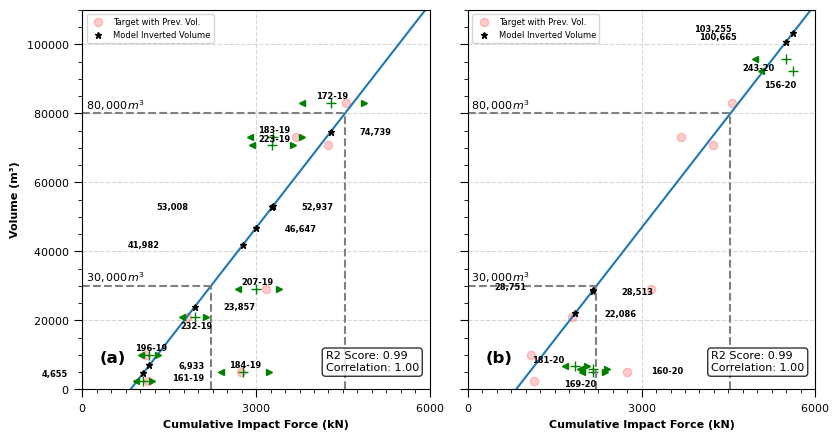

In [ ]:
# fig, ax = plt.subplots(nrows=1, ncols=2, sharex=True, sharey=True, figsize=(8.5,4.5))
# for axis in ax:
#     axis.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#     axis.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#     axis.xaxis.set_minor_locator(MultipleLocator(500))
#     axis.xaxis.set_major_locator(MultipleLocator(3_000))
#     axis.yaxis.set_major_locator(MultipleLocator(20_000))
#     axis.yaxis.set_minor_locator(MultipleLocator(5000))
#     axis.tick_params(axis='both', which='major', labelsize=8, length=6)
#     axis.tick_params(axis='both', which='minor', labelsize=7, length=3)
#     axis.set_xticks(range(0, 20_000+1, 3_000))
#     axis.set_yticks(range(0, 110_000+1, 20_000))
#     axis.set_xlim(0, 20_000);
#     axis.set_ylim(0, 110_000)
#     axis.plot(csum_list, volume_2019, 'ro', label = "Target with Prev. Vol.", alpha = 0.2)
#     axis.set_xlabel('Cumulative Impact Force (kN)', fontsize=8, fontweight="bold")
#     if axis == ax[0]:
#         axis.set_ylabel('Volume (m³)', fontsize=8, fontweight="bold")

# csum_list_2 = [csum_list[i] for i in [0, 1, 4, 6, 7]]
# volume_2019_2 = [volume_2019[i] for i in [0, 1, 4, 6, 7]]
# # csum_list_2 = [csum_list[i] for i in [1, 4, 5, 6, 7]]
# # volume_2019_2 = [volume_2019[i] for i in [1, 4, 5, 6, 7]]

# target_slope, target_intercept, _, _, _ = linregress(csum_list_2, volume_2019_2)
# print(f"Target Line of Best Fit: Slope = {target_slope:.4f}, Intercept = {target_intercept:.4f}")
# plot_x = np.linspace(0, 20_000, 50)
# for axis in ax:
#     axis.plot(plot_x, target_slope * plot_x + target_intercept, label = f"")

# # xLSTM Predictions
# ax[0].plot(results_2019['xLSTM'][:,0], volume_2019, 'g+', markersize=7)
# ax[0].plot(results_2019['xLSTM'][:,1], volume_2019, 'g<', markersize=4)
# ax[0].plot(results_2019['xLSTM'][:,2], volume_2019, 'g>', markersize=4)
# csum_estimate1 = [np.round(target_slope * csum + target_intercept) for csum in results_2019['xLSTM'][:,0]]
# ax[0].plot(results_2019['xLSTM'][:,0], csum_estimate1, 'k*', markersize=5, label="Model Inverted Volume")
# ## Label volume estimate 2019
# for csum, vol_est in zip(results_2019['xLSTM'][:,0], csum_estimate1):
#     if vol_est == csum_estimate1[2]:
#         ax[0].text(csum-2000, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")   
#     elif vol_est == csum_estimate1[3]:
#         ax[0].text(csum-2000, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")   
#     elif vol_est == 20898.0:
#         ax[0].text(csum-2800, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")   
#     elif vol_est == csum_estimate1[0]:
#         ax[0].text(csum-1750, vol_est-1200, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")   
#     elif vol_est == csum_estimate1[4]:
#         ax[0].text(csum+500, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")   
#     else: 
#         ax[0].text(csum+500, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
# ## Label julian day 2019
# for csum, vol, julday in zip(results_2019['xLSTM'][:,0], volume_2019, julday_list_2019):
#     if julday == "161-19":
#         ax[0].text(csum+500, vol, julday, fontdict={"size": 6, "weight": "bold"})
#     elif julday == "232-19":
#         ax[0].text(csum-250, vol-3500, julday, fontdict={"size": 6, "weight": "bold"})
#     else:
#         ax[0].text(csum-250, vol+1100, julday, fontdict={"size": 6, "weight": "bold"})

# ax[1].plot(results_2020['xLSTM'][:,0], volume_2020, 'g+', markersize=7)
# ax[1].plot(results_2020['xLSTM'][:,1], volume_2020, 'g<', markersize=4)
# ax[1].plot(results_2020['xLSTM'][:,2], volume_2020, 'g>', markersize=4)
# csum_estimate2 = [np.round(target_slope * csum + target_intercept) for csum in results_2020['xLSTM'][:,0]]
# ax[1].plot(results_2020['xLSTM'][:,0], csum_estimate2, 'k*', markersize=5, label="Model Inverted Volume")
# ## Label volume estimate 2020
# for csum, vol_est in zip(results_2020['xLSTM'][:,0], csum_estimate2):
#     if vol_est == csum_estimate2[0]:
#         ax[1].text(csum-1700, vol_est+500, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")    
#     elif vol_est == csum_estimate2[1]:
#         ax[1].text(csum-1700, vol_est, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")    
#     elif vol_est == csum_estimate2[-1]:
#         ax[1].text(csum-1500, vol_est+500, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")    
#     else:
#         ax[1].text(csum+500, vol_est-1200, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
# ## Label julian day 2020
# for csum, vol, julday in zip(results_2020['xLSTM'][:,0], volume_2020, julday_list_2020):
#     if julday == "156-20":
#         ax[1].text(csum-500, vol-5000, julday, fontdict={"size": 6, "weight": "bold"}) 
#     elif julday == '169-20':
#         ax[1].text(csum-500, vol-4500, julday, fontdict={"size": 6, "weight": "bold"}) 
#     elif julday == '160-20':
#         ax[1].text(csum+1000, vol-1500, julday, fontdict={"size": 6, "weight": "bold"}) 
#     elif julday == "243-20":
#         ax[1].text(csum-750, vol-3500, julday, fontdict={"size": 6, "weight": "bold"}) 
#     else:
#         ax[1].text(csum-750, vol+1100, julday, fontdict={"size": 6, "weight": "bold"})

# # ax[1].plot(results_2022['xLSTM'][:,0], volume_2022, 'g+', markersize=7)
# # ax[1].plot(results_2022['xLSTM'][:,1], volume_2022, 'g<', markersize=4)
# # ax[1].plot(results_2022['xLSTM'][:,2], volume_2022, 'g>', markersize=4)
# # csum_estimate3 = [np.round(target_slope * csum + target_intercept) for csum in results_2022['xLSTM'][:,0]]
# # ax[1].plot(results_2022['xLSTM'][:,0], csum_estimate3, 'k*', markersize=5, label="")
# # ## Label volume estimate 2022
# # for csum, vol_est in zip(results_2022['xLSTM'][:,0], csum_estimate3):
# #     if vol_est == 28268.0:
# #         ax[1].text(csum+500, vol_est+1000, f"{int(np.round(vol_est)):,}", fontsize=8, fontweight="bold")
# #     else:
# #         ax[1].text(csum+500, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=8, fontweight="bold")
# # ## Label julian day 2022
# # for csum, vol, julday in zip(results_2022['xLSTM'][:,0], volume_2022, julday_list_2022):
# #     ax[1].text(csum-750, vol+1000, julday, fontdict={"size": 6, "weight": "bold"})

# for axis in ax:
#     axis.legend(loc="upper left", fontsize=6)
#     axis.grid(True, linestyle="--", alpha=0.5)
#     axis.text(0.01, 31_000/110_000, r"$30,000m^3$", transform=axis.transAxes, fontsize=8)
#     axis.text(0.01, 81_000/110_000, r"$80,000m^3$", transform=axis.transAxes, fontsize=8)
#     y_val = 30_000
#     axis.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
#     axis.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')
#     y_val = 80_000
#     axis.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
#     axis.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')

# # R2 and Corr
# csum_list_2 = np.array(csum_list_2)
# volume_2019_2 = np.array(volume_2019_2)
# new_csum_scaled = (csum_list_2 - csum_list_2.min()) / (csum_list_2.max() - csum_list_2.min())
# new_vols_scaled = (volume_2019_2 - volume_2019_2.min()) / (volume_2019_2.max() - volume_2019_2.min())
# r2 = r2_score(new_csum_scaled, new_vols_scaled)
# corr, _ = stats.pearsonr(csum_list_2, volume_2019_2)
# info_text = f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}"
# ax[0].text(0.7, 0.1, info_text, transform=ax[0].transAxes, fontsize=8,
#     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
# ax[1].text(0.7, 0.1, info_text, transform=ax[1].transAxes, fontsize=8,
#     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ax[0].text(0.05, 0.1, "(a)", transform=ax[0].transAxes, fontsize=12, fontweight="bold", va='top', ha='left')
# ax[1].text(0.05, 0.1, "(b)", transform=ax[1].transAxes, fontsize=12, fontweight="bold", va='top', ha='left')

# fig.tight_layout()
# fig.savefig("./output_images3/Volume-CIF_5sec.png", dpi=600)

Target Line of Best Fit: Slope = 43.2377, Intercept = -18031.1819
Target Line of Best Fit: Slope = 14.4126, Intercept = -18031.1819
Target Line of Best Fit: Slope = 21.6189, Intercept = -18031.1819


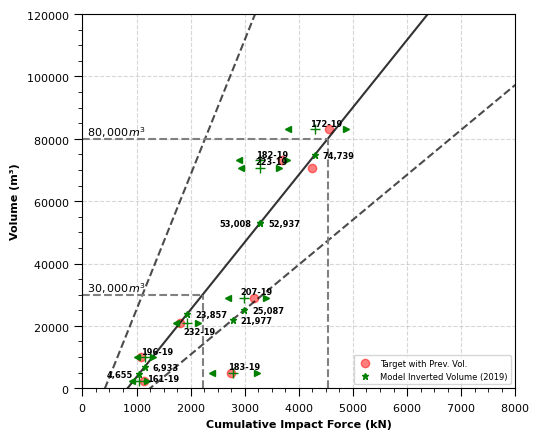

In [89]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=True, sharey=True, figsize=(5.5,4.5))
if interval_seconds == 5:
    xlim = 24_000
    xlim_major = 2_500
    xlim_minor = 500
elif interval_seconds == 15:
    xlim = 8_000
    xlim_major = 1_000
    xlim_minor = 250

ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.set_minor_locator(MultipleLocator(xlim_minor))
ax.xaxis.set_major_locator(MultipleLocator(xlim_major))
ax.yaxis.set_major_locator(MultipleLocator(20_000))
ax.yaxis.set_minor_locator(MultipleLocator(5_000))
ax.tick_params(axis='both', which='major', labelsize=8, length=6)
ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
ax.set_xticks(range(0, xlim+1, xlim_major))
ax.set_yticks(range(0, 120_000+1, 20_000))
ax.set_xlim(0, xlim);
ax.set_ylim(0, 120_000)
ax.plot(csum_list, volume_2019, 'ro', label = "Target with Prev. Vol.", alpha = 0.5)
ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=8, fontweight="bold")
ax.set_ylabel('Volume (m³)', fontsize=8, fontweight="bold")

csum_list_2 = np.array([csum_list[i] for i in [0, 1, 4, 6, 7]])
volume_2019_2 = np.array([volume_2019[i] for i in [0, 1, 4, 6, 7]])
lower_csum_list = csum_list_2 - csum_list_2 * 0.50
upper_csum_list = csum_list_2 + csum_list_2 * 0.50

target_slope_l, target_intercept_l, _, _, _ = linregress(lower_csum_list, volume_2019_2)
print(f"Target Line of Best Fit: Slope = {target_slope_l:.4f}, Intercept = {target_intercept_l:.4f}")
plot_x = np.linspace(0, xlim, 50)
ax.plot(plot_x, target_slope_l * plot_x + target_intercept_l, alpha=0.7, linestyle="--", color="k")

target_slope_u, target_intercept_u, _, _, _ = linregress(upper_csum_list, volume_2019_2)
print(f"Target Line of Best Fit: Slope = {target_slope_u:.4f}, Intercept = {target_intercept_u:.4f}")
plot_x = np.linspace(0, xlim, 50)
ax.plot(plot_x, target_slope_u * plot_x + target_intercept_u, alpha=0.7, linestyle="--", color="k")
    
target_slope, target_intercept, _, _, _ = linregress(csum_list_2, volume_2019_2)
print(f"Target Line of Best Fit: Slope = {target_slope:.4f}, Intercept = {target_intercept:.4f}")
plot_x = np.linspace(0, xlim, 50)
ax.plot(plot_x, target_slope * plot_x + target_intercept, alpha=0.8, linestyle="-", color="k")

# xLSTM Predictions
# 2019
ax.plot(results_2019['xLSTM'][:,0], volume_2019, 'g+', markersize=7)
ax.plot(results_2019['xLSTM'][:,1], volume_2019, 'g<', markersize=4)
ax.plot(results_2019['xLSTM'][:,2], volume_2019, 'g>', markersize=4)
# csum_estimate1 = [np.round(target_slope * csum + target_intercept) for csum in results_2019['xLSTM'][:,0]]
# ax.plot(results_2019['xLSTM'][:,0], csum_estimate1, 'k*', markersize=5, label="Model Inverted Volume")
## Label volume estimate 2019
csum_estimate_2019 = []
for i, csum in enumerate(results_2019['xLSTM'][:,0]):
    if i in []:
        vol_est = target_slope_l * csum + target_intercept_l
    elif i in [3, 5]:
        vol_est = target_slope_u * csum + target_intercept_u
    else:
        vol_est = target_slope * csum + target_intercept
    csum_estimate_2019.append(vol_est)
    if i in [2]:
        ax.text(csum-750, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")   
    elif i in [0]:
        ax.text(csum-600, vol_est-1200, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")   
    elif i in [4]:
        ax.text(csum+150, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")   
    else:
        ax.text(csum+150, vol_est-1000, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
ax.plot(results_2019['xLSTM'][:,0], csum_estimate_2019, 'g*', markersize=5, label="Model Inverted Volume (2019)")
for csum, vol, julday in zip(results_2019['xLSTM'][:,0], volume_2019, julday_list_2019):
    if julday == "161-19":
        ax.text(csum+150, vol, julday, fontdict={"size": 6, "weight": "bold"})
    elif julday == "232-19":
        ax.text(csum-80, vol-3500, julday, fontdict={"size": 6, "weight": "bold"})
    else:
        ax.text(csum-80, vol+1100, julday, fontdict={"size": 6, "weight": "bold"})

ax.legend(loc="best", fontsize=6)
ax.grid(True, linestyle="--", alpha=0.5)
ax.text(0.01, 31_000/120_000, r"$30,000m^3$", transform=ax.transAxes, fontsize=8)
ax.text(0.01, 81_000/120_000, r"$80,000m^3$", transform=ax.transAxes, fontsize=8)
y_val = 30_000
ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')
y_val = 80_000
ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')

fig.tight_layout()
fig.savefig("./output_images4/Volume-CIF_15sec_2019.png", dpi=600)
# plt.close(fig=fig)

In [138]:
######################################################################################
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=True, sharey=True, figsize=(5.5,4.5))
if interval_seconds == 5:
    xlim = 24_000
    xlim_major = 2_500
    xlim_minor = 500
elif interval_seconds == 15:
    xlim = 8_000
    xlim_major = 1_000
    xlim_minor = 250

ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.set_minor_locator(MultipleLocator(xlim_minor))
ax.xaxis.set_major_locator(MultipleLocator(xlim_major))
ax.yaxis.set_major_locator(MultipleLocator(20_000))
ax.yaxis.set_minor_locator(MultipleLocator(5_000))
ax.tick_params(axis='both', which='major', labelsize=8, length=6)
ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
ax.set_xticks(range(0, xlim+1, xlim_major))
ax.set_yticks(range(0, 130_000+1, 20_000))
ax.set_xlim(0, xlim);
ax.set_ylim(0, 130_000)
ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=8, fontweight="bold")
ax.set_ylabel('Volume (m³)', fontsize=8, fontweight="bold")

csum_list_2 = np.array([csum_list[i] for i in [0, 1, 4, 6, 7]])
volume_2019_2 = np.array([volume_2019[i] for i in [0, 1, 4, 6, 7]])
lower_csum_list = csum_list_2 - csum_list_2 * 0.50
upper_csum_list = csum_list_2 + csum_list_2 * 0.50

target_slope_l, target_intercept_l, _, _, _ = linregress(lower_csum_list, volume_2019_2)
print(f"Target Line of Best Fit: Slope = {target_slope_l:.4f}, Intercept = {target_intercept_l:.4f}")
plot_x = np.linspace(0, xlim, 50)
ax.plot(plot_x, target_slope_l * plot_x + target_intercept_l, alpha=0.7, linestyle="--", color="k")

target_slope_u, target_intercept_u, _, _, _ = linregress(upper_csum_list, volume_2019_2)
print(f"Target Line of Best Fit: Slope = {target_slope_u:.4f}, Intercept = {target_intercept_u:.4f}")
plot_x = np.linspace(0, xlim, 50)
ax.plot(plot_x, target_slope_u * plot_x + target_intercept_u, alpha=0.7, linestyle="--", color="k")
    
target_slope, target_intercept, _, _, _ = linregress(csum_list_2, volume_2019_2)
print(f"Target Line of Best Fit: Slope = {target_slope:.4f}, Intercept = {target_intercept:.4f}")
plot_x = np.linspace(0, xlim, 50)
ax.plot(plot_x, target_slope * plot_x + target_intercept, alpha=0.8, linestyle="-", color="k")

# 2020
ax.plot(results_2020['xLSTM'][:,0], volume_2020, 'r+', markersize=7, label="2020")
ax.plot(results_2020['xLSTM'][:,1], volume_2020, 'r<', markersize=4)
ax.plot(results_2020['xLSTM'][:,2], volume_2020, 'r>', markersize=4)
csum_estimate_2020 = []
for i, csum in enumerate(results_2020['xLSTM'][:,0]):
    if i in [1, 2, 3]:
        vol_est = target_slope_u * csum + target_intercept_u
    else:
        vol_est = target_slope * csum + target_intercept
    csum_estimate_2020.append(vol_est)
    if i in [0, 4]:
        ax.text(csum-750, vol_est+500, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
    elif i in [1]:
        ax.text(csum-750, vol_est, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")  
    elif i in [3]:
        ax.text(csum-750, vol_est, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")  
    else:
        ax.text(csum+150, vol_est-1200, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
ax.plot(results_2020['xLSTM'][:,0], csum_estimate_2020, 'r*', markersize=5, label="Model Inverted Volume (2020)")
for csum, vol, julday in zip(results_2020['xLSTM'][:,0], volume_2020, julday_list_2020):
    if julday == "156-20":
        ax.text(csum-150, vol-5000, julday, fontdict={"size": 6, "weight": "bold"}) 
    elif julday == '169-20':
        ax.text(csum-150, vol-4500, julday, fontdict={"size": 6, "weight": "bold"}) 
    elif julday == '160-20':
        ax.text(csum+350, vol-1500, julday, fontdict={"size": 6, "weight": "bold"}) 
    elif julday == "243-20":
        ax.text(csum-250, vol-3500, julday, fontdict={"size": 6, "weight": "bold"}) 
    else:
        ax.text(csum-250, vol+1100, julday, fontdict={"size": 6, "weight": "bold"})

# 2022
ax.plot(results_2022['xLSTM'][:,0], volume_2022, 'g+', markersize=7, label="2022")
ax.plot(results_2022['xLSTM'][:,1], volume_2022, 'g<', markersize=4)
ax.plot(results_2022['xLSTM'][:,2], volume_2022, 'g>', markersize=4)
csum_estimate_2022 = []
for i, csum in enumerate(results_2022['xLSTM'][:,0]):
    if i in [1]:
        vol_est = target_slope_l * csum + target_intercept_l
    else:
        vol_est = target_slope * csum + target_intercept
    csum_estimate_2022.append(vol_est)
    ax.text(csum+150, vol_est-1200, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
ax.plot(results_2022['xLSTM'][:,0], csum_estimate_2022, 'g*', markersize=5, label="Model Inverted Volume (2022)")
for csum, vol, julday in zip(results_2022['xLSTM'][:,0], volume_2022, julday_list_2022):
    ax.text(csum-250, vol+1100, julday, fontdict={"size": 6, "weight": "bold"})


ax.legend(loc="best", fontsize=6)
ax.grid(True, linestyle="--", alpha=0.5)
ax.text(0.01, 31_000/130_000, r"$30,000m^3$", transform=ax.transAxes, fontsize=8)
ax.text(0.01, 81_000/130_000, r"$80,000m^3$", transform=ax.transAxes, fontsize=8)
y_val = 30_000
ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')
y_val = 80_000
ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')

fig.tight_layout()
fig.savefig("./output_images4/Volume-CIF_15sec_2020-22.png", dpi=600)
plt.close(fig=fig)
#############################################################################################
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=True, sharey=True, figsize=(5.5,4.5))
if interval_seconds == 5:
    xlim = 24_000
    xlim_major = 2_500
    xlim_minor = 500
elif interval_seconds == 15:
    xlim = 8_000
    xlim_major = 1_000
    xlim_minor = 250
# for axis in ax:
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.set_minor_locator(MultipleLocator(xlim_minor))
ax.xaxis.set_major_locator(MultipleLocator(xlim_major))
ax.yaxis.set_major_locator(MultipleLocator(20_000))
ax.yaxis.set_minor_locator(MultipleLocator(5_000))
ax.tick_params(axis='both', which='major', labelsize=8, length=6)
ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
ax.set_xticks(range(0, xlim+1, xlim_major))
ax.set_yticks(range(0, 130_000+1, 20_000))
ax.set_xlim(0, xlim);
ax.set_ylim(0, 130_000)
ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=8, fontweight="bold")
ax.set_ylabel('Volume (m³)', fontsize=8, fontweight="bold")

csum_list_2 = np.array([csum_list[i] for i in [0, 1, 4, 6, 7]])
volume_2019_2 = np.array([volume_2019[i] for i in [0, 1, 4, 6, 7]])
lower_csum_list = csum_list_2 - csum_list_2 * 0.50
upper_csum_list = csum_list_2 + csum_list_2 * 0.50

target_slope_l, target_intercept_l, _, _, _ = linregress(lower_csum_list, volume_2019_2)
print(f"Target Line of Best Fit: Slope = {target_slope_l:.4f}, Intercept = {target_intercept_l:.4f}")
plot_x = np.linspace(0, xlim, 50)
ax.plot(plot_x, target_slope_l * plot_x + target_intercept_l, alpha=0.7, linestyle="--", color="k")

target_slope_u, target_intercept_u, _, _, _ = linregress(upper_csum_list, volume_2019_2)
print(f"Target Line of Best Fit: Slope = {target_slope_u:.4f}, Intercept = {target_intercept_u:.4f}")
plot_x = np.linspace(0, xlim, 50)
ax.plot(plot_x, target_slope_u * plot_x + target_intercept_u, alpha=0.7, linestyle="--", color="k")
    
target_slope, target_intercept, _, _, _ = linregress(csum_list_2, volume_2019_2)
print(f"Target Line of Best Fit: Slope = {target_slope:.4f}, Intercept = {target_intercept:.4f}")
plot_x = np.linspace(0, xlim, 50)
ax.plot(plot_x, target_slope * plot_x + target_intercept, alpha=0.8, linestyle="-", color="k")

# 2021
ax.plot(results_2021['xLSTM'][:,0], volume_2021, 'b+', markersize=7, label="2021")
ax.plot(results_2021['xLSTM'][:,1], volume_2021, 'b<', markersize=4)
ax.plot(results_2021['xLSTM'][:,2], volume_2021, 'b>', markersize=4)
csum_estimate_2021 = []
for i, csum in enumerate(results_2021['xLSTM'][:,0]):
    if i in [3, 5, 6, 7]:
        vol_est = target_slope_l * csum + target_intercept_l
    elif i in [4, 8, 9, 10]:
        vol_est = target_slope_u * csum + target_intercept_u
    else:
        vol_est = target_slope * csum + target_intercept
    csum_estimate_2021.append(vol_est)
    if i in [2, 3, 4, 5, 6, 7]:
        ax.text(csum-650, vol_est-1200, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
    else:
        ax.text(csum+150, vol_est-1200, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
ax.plot(results_2021['xLSTM'][:,0], csum_estimate_2021, 'b*', markersize=5, label="Model Inverted Volume (2021)")
for csum, vol, julday in zip(results_2021['xLSTM'][:,0], volume_2021, julday_list_2021):
    if julday in ["142-21", "173-21"]:
        ax.text(csum-250, vol-3000, julday, fontdict={"size": 6, "weight": "bold"})
    elif julday in ["262-21"]:
        ax.text(csum+250, vol-500, julday, fontdict={"size": 6, "weight": "bold"})
    else:
        ax.text(csum-250, vol+1100, julday, fontdict={"size": 6, "weight": "bold"})

# 2023
ax.plot(results_2023['xLSTM'][:,0], volume_2023, 'm+', markersize=7, label="2023")
ax.plot(results_2023['xLSTM'][:,1], volume_2023, 'm<', markersize=4)
ax.plot(results_2023['xLSTM'][:,2], volume_2023, 'm>', markersize=4)
csum_estimate_2023 = []
for i, csum in enumerate(results_2023['xLSTM'][:,0]):
    if i in [0, 1]:
        vol_est = vol_est = target_slope_u * csum + target_intercept_u
    else:
        vol_est = vol_est = target_slope_l * csum + target_intercept_l
    csum_estimate_2023.append(vol_est)
    ax.text(csum+150, vol_est-1200, f"{int(np.round(vol_est)):,}", fontsize=6, fontweight="bold")
ax.plot(results_2023['xLSTM'][:,0], csum_estimate_2023, 'm*', markersize=5, label="Model Inverted Volume (2023)")
for csum, vol, julday in zip(results_2023['xLSTM'][:,0], volume_2023, julday_list_2023):
    ax.text(csum-250, vol+1100, julday, fontdict={"size": 6, "weight": "bold"})

# for axis in ax:
ax.legend(loc="best", fontsize=6)
ax.grid(True, linestyle="--", alpha=0.5)
ax.text(0.01, 31_000/130_000, r"$30,000m^3$", transform=ax.transAxes, fontsize=8)
ax.text(0.01, 81_000/130_000, r"$80,000m^3$", transform=ax.transAxes, fontsize=8)
y_val = 30_000
ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')
y_val = 80_000
ax.vlines((y_val - target_intercept)/target_slope, ymin=0, ymax=y_val, colors='grey', linestyles='dashed')
ax.hlines(y_val, xmin=0, xmax=(y_val - target_intercept)/target_slope, colors='grey', linestyles='dashed')

# R2 and Corr
# csum_list_2 = np.array(csum_list_2)
# volume_2019_2 = np.array(volume_2019_2)
# new_csum_scaled = (csum_list_2 - csum_list_2.min()) / (csum_list_2.max() - csum_list_2.min())
# new_vols_scaled = (volume_2019_2 - volume_2019_2.min()) / (volume_2019_2.max() - volume_2019_2.min())
# r2 = r2_score(new_csum_scaled, new_vols_scaled)
# corr, _ = stats.pearsonr(csum_list_2, volume_2019_2)
# info_text = f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}"
# ax[0].text(0.7, 0.1, info_text, transform=ax[0].transAxes, fontsize=8,
#     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
# ax[1].text(0.7, 0.1, info_text, transform=ax[1].transAxes, fontsize=8,
#     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ax[0].text(0.9, 0.9, "(a)", transform=ax[0].transAxes, fontsize=12, fontweight="bold", va='top', ha='left')
# ax[1].text(0.9, 0.9, "(b)", transform=ax[1].transAxes, fontsize=12, fontweight="bold", va='top', ha='left')
# ax[2].text(0.9, 0.9, "(c)", transform=ax[2].transAxes, fontsize=12, fontweight="bold", va='top', ha='left')

fig.tight_layout()
fig.savefig("./output_images4/Volume-CIF_15sec_2021-23.png", dpi=600)
plt.close(fig=fig)

Target Line of Best Fit: Slope = 43.2377, Intercept = -18031.1819
Target Line of Best Fit: Slope = 14.4126, Intercept = -18031.1819
Target Line of Best Fit: Slope = 21.6189, Intercept = -18031.1819
Target Line of Best Fit: Slope = 43.2377, Intercept = -18031.1819
Target Line of Best Fit: Slope = 14.4126, Intercept = -18031.1819
Target Line of Best Fit: Slope = 21.6189, Intercept = -18031.1819


In [139]:
results_df = pd.DataFrame(columns=["Year", "Julian-Day", "Volume", "Estimated Volume Lower", "Estimated Volume", "Estimated Volume Upper", "CIF"])
year = 2019
for i, (julday, vol) in enumerate(zip(julday_list_2019, volume_2019)):
    julday = int(julday.split("-")[0])
    csum, csum_lower, csum_upper = results_2019['xLSTM'][i,:]
    csum, csum_lower, csum_upper = np.round(csum), np.round(csum_lower), np.round(csum_upper)
    if julday in [183, 207]:
        vol_est = np.round(target_slope_u * csum + target_intercept_u)
        vol_est_lower = np.round(target_slope_u * csum_lower + target_intercept_u)
        vol_est_upper = np.round(target_slope_u * csum_upper + target_intercept_u)
    elif julday in []:
        vol_est = np.round(target_slope_l * csum + target_intercept_l)
        vol_est_lower = np.round(target_slope_l * csum_lower + target_intercept_l)
        vol_est_upper = np.round(target_slope_l * csum_upper + target_intercept_l)
    else:
        vol_est = np.round(target_slope * csum + target_intercept)
        vol_est_lower = np.round(target_slope * csum_lower + target_intercept)
        vol_est_upper = np.round(target_slope * csum_upper + target_intercept)
    results_df.loc[len(results_df)] = [year, julday, vol, vol_est_lower, vol_est, vol_est_upper, csum]

year = 2020
for i, (julday, vol) in enumerate(zip(julday_list_2020, volume_2020)):
    julday = int(julday.split("-")[0])
    csum, csum_lower, csum_upper = results_2020['xLSTM'][i,:]
    csum, csum_lower, csum_upper = np.round(csum), np.round(csum_lower), np.round(csum_upper)
    if julday in [160, 169, 181]:
        vol_est = np.round(target_slope_u * csum + target_intercept_u)
        vol_est_lower = np.round(target_slope_u * csum_lower + target_intercept_u)
        vol_est_upper = np.round(target_slope_u * csum_upper + target_intercept_u)
    elif julday in []:
        vol_est = np.round(target_slope_l * csum + target_intercept_l)
        vol_est_lower = np.round(target_slope_l * csum_lower + target_intercept_l)
        vol_est_upper = np.round(target_slope_l * csum_upper + target_intercept_l)
    else:
        vol_est = np.round(target_slope * csum + target_intercept)
        vol_est_lower = np.round(target_slope * csum_lower + target_intercept)
        vol_est_upper = np.round(target_slope * csum_upper + target_intercept)
    results_df.loc[len(results_df)] = [year, julday, vol, vol_est_lower, vol_est, vol_est_upper, csum]

year = 2021
for i, (julday, vol) in enumerate(zip(julday_list_2021, volume_2021)):
    julday = int(julday.split("-")[0])
    csum, csum_lower, csum_upper = results_2021['xLSTM'][i,:]
    csum, csum_lower, csum_upper = np.round(csum), np.round(csum_lower), np.round(csum_upper)
    if julday in [173, 197, 219, 262]:
        vol_est = np.round(target_slope_u * csum + target_intercept_u)
        vol_est_lower = np.round(target_slope_u * csum_lower + target_intercept_u)
        vol_est_upper = np.round(target_slope_u * csum_upper + target_intercept_u)
    elif julday in [156, 175, 187, 194]:
        vol_est = np.round(target_slope_l * csum + target_intercept_l)
        vol_est_lower = np.round(target_slope_l * csum_lower + target_intercept_l)
        vol_est_upper = np.round(target_slope_l * csum_upper + target_intercept_l)
    else:
        vol_est = np.round(target_slope * csum + target_intercept)
        vol_est_lower = np.round(target_slope * csum_lower + target_intercept)
        vol_est_upper = np.round(target_slope * csum_upper + target_intercept)
    results_df.loc[len(results_df)] = [year, julday, vol, vol_est_lower, vol_est, vol_est_upper, csum]

year = 2022
for i, (julday, vol) in enumerate(zip(julday_list_2022, volume_2022)):
    julday = int(julday.split("-")[0])
    csum, csum_lower, csum_upper = results_2022['xLSTM'][i,:]
    csum, csum_lower, csum_upper = np.round(csum), np.round(csum_lower), np.round(csum_upper)
    if julday in []:
        vol_est = np.round(target_slope_u * csum + target_intercept_u)
        vol_est_lower = np.round(target_slope_u * csum_lower + target_intercept_u)
        vol_est_upper = np.round(target_slope_u * csum_upper + target_intercept_u)
    elif julday in [185]:
        vol_est = np.round(target_slope_l * csum + target_intercept_l)
        vol_est_lower = np.round(target_slope_l * csum_lower + target_intercept_l)
        vol_est_upper = np.round(target_slope_l * csum_upper + target_intercept_l)
    else:
        vol_est = np.round(target_slope * csum + target_intercept)
        vol_est_lower = np.round(target_slope * csum_lower + target_intercept)
        vol_est_upper = np.round(target_slope * csum_upper + target_intercept)
    results_df.loc[len(results_df)] = [year, julday, vol, vol_est_lower, vol_est, vol_est_upper, csum]

year = 2023
for i, (julday, vol) in enumerate(zip(julday_list_2023, volume_2023)):
    julday = int(julday.split("-")[0])
    csum, csum_lower, csum_upper = results_2023['xLSTM'][i,:]
    csum, csum_lower, csum_upper = np.round(csum), np.round(csum_lower), np.round(csum_upper)
    if julday in [153, 161]:
        vol_est = np.round(target_slope_u * csum + target_intercept_u)
        vol_est_lower = np.round(target_slope_u * csum_lower + target_intercept_u)
        vol_est_upper = np.round(target_slope_u * csum_upper + target_intercept_u)
    elif julday in [193]:
        vol_est = np.round(target_slope_l * csum + target_intercept_l)
        vol_est_lower = np.round(target_slope_l * csum_lower + target_intercept_l)
        vol_est_upper = np.round(target_slope_l * csum_upper + target_intercept_l)
    else:
        vol_est = np.round(target_slope * csum + target_intercept)
        vol_est_lower = np.round(target_slope * csum_lower + target_intercept)
        vol_est_upper = np.round(target_slope * csum_upper + target_intercept)
    results_df.loc[len(results_df)] = [year, julday, vol, vol_est_lower, vol_est, vol_est_upper, csum]


In [140]:
results_df["Uncertainty_Lower"] = np.round((results_df['Estimated Volume'] - results_df['Estimated Volume Lower']) * 100 / results_df['Estimated Volume'],2)
results_df["Uncertainty_Upper"] = np.round((results_df['Estimated Volume Upper'] - results_df['Estimated Volume']) * 100 / results_df['Estimated Volume'],2)
results_df["Estimated"] = ["Yes" if j < i < k else "No" for idx, (i,j,k) in results_df.loc[:, ['Volume', "Estimated Volume Lower", "Estimated Volume Upper"]].iterrows()]
results_df["Absolute_Error"] = [np.round(np.abs(i - j)) for idx, (i,j) in results_df.loc[:, ['Volume', "Estimated Volume"]].iterrows()]
results_df['Percent_Error'] = np.round(results_df['Absolute_Error'] / results_df['Volume'], 4) * 100

In [141]:
results_df.to_csv("./output_images4/vol_estimates.csv")

In [111]:
results_df

,Year,Julian-Day,Volume,Estimated Volume Lower,Estimated Volume,Estimated Volume Upper,Uncertainty_Lower,Uncertainty_Upper,Estimated,Absolute_Error,Percent_Error
0,2019.0,161.0,2313.0,1966.0,4647.0,7825.0,57.69,68.39,Yes,2334.0,100.91
1,2019.0,172.0,83123.0,63991.0,74735.0,87209.0,14.38,16.69,Yes,8388.0,10.09
2,2019.0,182.0,73144.0,44447.0,53008.0,63904.0,16.15,20.56,No,20136.0,27.53
3,2019.0,183.0,4959.0,16372.0,21978.0,28536.0,25.51,29.84,No,17019.0,343.19
4,2019.0,196.0,9869.0,3804.0,6939.0,10095.0,45.18,45.48,Yes,2930.0,29.69
5,2019.0,207.0,29077.0,20782.0,25091.0,30813.0,17.17,22.80,Yes,3986.0,13.71
6,2019.0,223.0,70705.0,45161.0,52944.0,60640.0,14.70,14.54,No,17761.0,25.12
7,2019.0,232.0,21031.0,19348.0,23866.0,28233.0,18.93,18.30,Yes,2835.0,13.48
8,2020.0,156.0,92424.0,91576.0,103251.0,115660.0,11.31,12.02,Yes,10827.0,11.71
9,2020.0,160.0,5872.0,9972.0,13158.0,16487.0,24.21,25.30,No,7286.0,124.08


In [114]:
from collections import Counter
Counter(results_df['Estimated'])

Counter({'No': 15, 'Yes': 14})

In [136]:
temp = results_df[results_df['Volume'] > 10000]
print(len(temp[temp['Percent_Error'] < 30]))
print(Counter(temp['Estimated']))

15
Counter({'Yes': 11, 'No': 8})


# Compare CFS and CIF

In [165]:
[print(f"{UTCDateTime(year=2020, julday=jul.split("-")[0]).date}\t{jul}\t{CIF}") for jul, CIF in zip(julday_list_2020, results_2020['xLSTM'][:,0])];

2020-06-04	156-20	5610.21634015
2020-06-08	160-20	2163.9360265249998
2020-06-17	169-20	2152.92240055
2020-06-29	181-20	1855.6752588875
2020-08-30	243-20	5490.4147802625


# Looking into seismic signatures

In [71]:
from obspy import Stream, Trace, UTCDateTime
from obspy.signal.filter import envelope

from functions.data_processing.read_data import load_label, load_label2, load_seismic_data_test

In [72]:
year = 2019
juldays_2019 = [161, 172, 182, 183, 196, 207, 223, 232]
event_ids_2019 = ["1", "3", "4", "5", "6", "7", "8", "9"]

year = 2020
juldays_2020 = [156, 160, 169, 181, 243] # 159
start_times_2020 = ["2020-06-04 15:30:00", "2020-06-08 17:30:00", "2020-06-17 04:30:00", "2020-06-29 05:00:00", "2020-08-30 05:45:00"] # "2020-06-07 09:00:00"
end_times_2020 = ["2020-06-04 18:00:00", "2020-06-08 21:00:00", "2020-06-17 07:00:00", "2020-06-29 07:30:00", "2020-08-30 12:00:00"] # "2020-06-07 10:30:00"

year = 2021
juldays_2021 = [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]
start_times_2021 = ["2021-05-11 13:30:00", "2021-05-16 15:30:00", "2021-05-21 22:00:00", "2021-06-05 09:00:00",
            "2021-06-22 19:00:00", "2021-06-24 15:00:00", "2021-07-06 18:30:00", "2021-07-13 15:00:00",
            "2021-07-16 03:30:00", "2021-08-07 13:30:00", "2021-09-19 05:30:00"]
end_times_2021 = ["2021-05-11 19:30:00", "2021-05-16 22:00:00", "2021-05-22 02:30:00", "2021-06-05 13:00:00",
            "2021-06-22 22:30:00", "2021-06-24 19:00:00", "2021-07-06 22:00:00", "2021-07-13 20:00:00",
            "2021-07-16 08:00:00", "2021-08-07 18:00:00", "2021-09-19 12:30:00"]

year = 2022
juldays_2022 = [156, 185]
start_times_2022 = ["2022-06-05 11:15:00", "2022-07-04 21:40:00"]
end_times_2022 = ["2022-06-05 13:30:00", "2022-07-04 23:59:59"]

year = 2023
juldays_2023 = [153, 161, 193]
start_times_2023 = ["2023-06-02 17:00:00", "2023-06-10 05:00:00", "2023-07-12 03:30:00"]
end_times_2023 = ["2023-06-02 21:30:00", "2023-06-10 09:30:00", "2023-07-12 06:00:00"]

In [73]:
# all_streams = Stream()

In [74]:
# for year in [2019]:
#     if year == 2019:
#         juldays = juldays_2019
#         event_ids = event_ids_2019
#     elif year == 2020:
#         juldays = juldays_2020
#     elif year == 2022:
#         juldays = juldays_2022
#     for julday in juldays:
#         print(f"Year: {year}, Julday: {julday}")
#         if julday in [182, 183]:
#             st = Stream()
#             st += load_seismic_data_test(julday, "ILL11", year, "EHZ", "9S")
#             st += load_seismic_data_test(julday+1, "ILL11", year, "EHZ", "9S")
#             st.merge(method=1, fill_value='latest', interpolation_samples=0)
#         else:
#             st = load_seismic_data_test(julday, "ILL11", year, "EHZ", "9S")
#         if year == 2019:
#             idx = juldays_2019.index(julday)
#             event_id = event_ids_2019[idx]
#             st.trim(UTCDateTime(event_id_map[event_id]['start_time']), UTCDateTime(event_id_map[event_id]['end_time']))
#         elif year == 2020:
#             idx = juldays_2020.index(julday)
#             st.trim(UTCDateTime(start_times_2020[idx]), UTCDateTime(end_times_2020[idx]))
#         elif year == 2022:
#             idx = juldays_2022.index(julday)
#             st.trim(UTCDateTime(start_times_2022[idx]), UTCDateTime(end_times_2022[idx]))
#         # all_streams[f"{year}-{julday}"] = st.copy()
#         all_streams += st.copy()

In [ ]:
# hourlines = [i * 100 * 1800 for i in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]]
# hourlabels = [0.5 * i for i in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]]

In [75]:
# fig, ax = plt.subplots(5, 1, figsize=(8, 8), sharex=True, sharey=True)
# for tr in all_streams:
#     if (tr.stats.starttime.year == 2019) and (tr.stats.starttime.julday == 172):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[0].plot(times, tr.data, "k-",linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#         # ax[0].plot(times, envelope(tr.data), "k-",linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}", linestyle=":")
#     if (tr.stats.starttime.year == 2019) and (tr.stats.starttime.julday == 207):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[1].plot(times, tr.data, "k-",linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#     if (tr.stats.starttime.year == 2020) and (tr.stats.starttime.julday == 156):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[2].plot(times, tr.data, "k-",linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#     if (tr.stats.starttime.year == 2020) and (tr.stats.starttime.julday == 243):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[3].plot(times, tr.data, "k-",linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#     if (tr.stats.starttime.year == 2022) and (tr.stats.starttime.julday == 185):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[4].plot(times, tr.data, "k-",linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")

# for axes in ax:
#     axes.legend(fontsize=8)
#     axes.set_yticks(np.arange(-1.5, 1.6, 0.5), np.arange(-1.5, 1.6, 0.5))
#     axes.set_ylim(-1.5, 1.5)
#     # axes.vlines(hourlines, ymin=-2, ymax=2, linestyle="--", alpha=0.8, color="k")
#     axes.set_xticks(hourlines, hourlabels)
#     axes.grid(True, linestyle='--', alpha=0.7)
#     axes.set_xlim(0, 6 * 100 * 3600)

# fig.tight_layout()
# fig.savefig(f"./output_images2/high-vol-seis.png", dpi=300)

In [76]:
# fig, ax = plt.subplots(5, 1, figsize=(8, 8), sharex=True, sharey=True)
# for tr in all_streams:
#     if (tr.stats.starttime.year == 2019) and (tr.stats.endtime.julday == 183):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.endtime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[0].plot(times, tr.data, "k-", linewidth=0.5, label=f"{tr.stats.endtime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#         # ax[0].plot(times, envelope(tr.data), linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}", linestyle=":")
#     if (tr.stats.starttime.year == 2019) and (tr.stats.starttime.julday == 207):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[1].plot(times, tr.data, "k-", linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#     if (tr.stats.starttime.year == 2019) and (tr.stats.starttime.julday == 223):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[2].plot(times, tr.data, "k-", linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#     if (tr.stats.starttime.year == 2019) and (tr.stats.endtime.julday == 184):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.endtime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[3].plot(times, tr.data, "k-", linewidth=0.5, label=f"{tr.stats.endtime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#     if (tr.stats.starttime.year == 2022) and (tr.stats.starttime.julday == 156):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[4].plot(times, tr.data, "k-", linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")

# for axes in ax:
#     axes.set_xlim(left=0)
#     axes.legend(fontsize=8)

# for axes in ax:
#     axes.legend(fontsize=8)
#     axes.set_yticks(np.arange(-1.5, 1.6, 0.5), np.arange(-1.5, 1.6, 0.5))
#     axes.set_ylim(-1.5, 1.5)
#     # axes.vlines(hourlines, ymin=-2, ymax=2, linestyle="--", alpha=0.8, color="k")
#     axes.set_xticks(hourlines, hourlabels)
#     axes.grid(True, linestyle='--', alpha=0.7)
#     axes.set_xlim(0, 3 * 100 * 3600)
    
# fig.tight_layout()
# fig.savefig(f"./output_images2/med-vol-seis.png", dpi=300)

In [77]:
# fig, ax = plt.subplots(6, 1, figsize=(8, 8), sharex=True, sharey=True)
# for tr in all_streams:
#     if (tr.stats.starttime.year == 2019) and (tr.stats.endtime.julday == 161):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.endtime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[0].plot(times, tr.data, "k-", linewidth=0.5, label=f"{tr.stats.endtime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#         # ax[0].plot(times, envelope(tr.data), linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}", linestyle=":")
#     if (tr.stats.starttime.year == 2019) and (tr.stats.starttime.julday == 196):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[1].plot(times, tr.data, "k-", linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#     if (tr.stats.starttime.year == 2019) and (tr.stats.starttime.julday == 232):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[2].plot(times, tr.data, "k-", linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#     if (tr.stats.starttime.year == 2020) and (tr.stats.endtime.julday == 160):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.endtime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[3].plot(times, tr.data, "k-", linewidth=0.5, label=f"{tr.stats.endtime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#     if (tr.stats.starttime.year == 2020) and (tr.stats.starttime.julday == 169):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[4].plot(times, tr.data, "k-", linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#     if (tr.stats.starttime.year == 2020) and (tr.stats.starttime.julday == 181):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[5].plot(times, tr.data, "k-", linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")

# for axes in ax:
#     axes.set_xlim(left=0)
#     axes.legend(fontsize=8)

# for axes in ax:
#     axes.legend(fontsize=8)
#     axes.set_yticks(np.arange(-1.5, 1.6, 0.5), np.arange(-1.5, 1.6, 0.5))
#     axes.set_ylim(-1.5, 1.5)
#     # axes.vlines(hourlines, ymin=-2, ymax=2, linestyle="--", alpha=0.8, color="k")
#     axes.set_xticks(hourlines, hourlabels)
#     axes.grid(True, linestyle='--', alpha=0.7)
#     axes.set_xlim(0, 2 * 100 * 3600)
    
# fig.tight_layout()
# fig.savefig(f"./output_images2/low-vol-seis.png", dpi=300)

In [78]:
# fig, ax = plt.subplots(8, 1, figsize=(8, 12), sharex=True, sharey=True)
# for tr in all_streams:
#     if (tr.stats.starttime.year == 2019) and (tr.stats.starttime.julday == 172):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[0].plot(times, tr.data, "k-",linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#         # ax[0].plot(times, envelope(tr.data), "k-",linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}", linestyle=":")
#     if (tr.stats.starttime.year == 2019) and (tr.stats.endtime.julday == 183):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.endtime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[1].plot(times, tr.data, "k-", linewidth=0.5, label=f"{tr.stats.endtime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#     if (tr.stats.starttime.year == 2019) and (tr.stats.endtime.julday == 184):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.endtime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[2].plot(times, tr.data, "k-", linewidth=0.5, label=f"{tr.stats.endtime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#     if (tr.stats.starttime.year == 2019) and (tr.stats.starttime.julday == 207):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[3].plot(times, tr.data, "k-",linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#     if (tr.stats.starttime.year == 2019) and (tr.stats.starttime.julday == 223):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[4].plot(times, tr.data, "k-",linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#     if (tr.stats.starttime.year == 2019) and (tr.stats.starttime.julday == 161):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[5].plot(times, tr.data, "k-",linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#     if (tr.stats.starttime.year == 2019) and (tr.stats.starttime.julday == 196):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[6].plot(times, tr.data, "k-",linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
#     if (tr.stats.starttime.year == 2019) and (tr.stats.starttime.julday == 232):
#         times = np.arange(0, tr.stats.npts)
#         key = f"{tr.stats.starttime.julday}-{str(tr.stats.starttime.year)[-2:]}"
#         ax[7].plot(times, tr.data, "k-",linewidth=0.5, label=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}\nvol = {volume_dict[key]}")
# for axes in ax:
#     axes.legend(fontsize=8)
#     axes.set_yticks(np.arange(-1.5, 1.6, 0.5), np.arange(-1.5, 1.6, 0.5))
#     axes.set_ylim(-1.5, 1.5)
#     # axes.vlines(hourlines, ymin=-2, ymax=2, linestyle="--", alpha=0.8, color="k")
#     axes.set_xticks(hourlines, hourlabels)
#     axes.grid(True, linestyle='--', alpha=0.7)
#     axes.set_xlim(0, 2.5 * 100 * 3600)

# fig.tight_layout()
# fig.savefig(f"./output_images2/2019-seis.png", dpi=300)
# plt.close(fig=fig)

In [44]:
# fig, ax = plt.subplots(5, 1, figsize=(12, 12))
# for tr in all_streams:
#     if (tr.stats.starttime.year == 2019) and (tr.stats.starttime.julday == 172):
#         tr.spectrogram(axes=ax[0], title=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}", log=False, dbscale=True, cmap='inferno')
#     if (tr.stats.starttime.year == 2019) and (tr.stats.starttime.julday == 207):
#         tr.spectrogram(axes=ax[1], title=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}", log=False, dbscale=True, cmap='inferno')
#     if (tr.stats.starttime.year == 2020) and (tr.stats.starttime.julday == 156):
#         tr.spectrogram(axes=ax[2], title=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}", log=False, dbscale=True, cmap='inferno')
#     if (tr.stats.starttime.year == 2020) and (tr.stats.starttime.julday == 243):
#         tr.spectrogram(axes=ax[3], title=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}", log=False, dbscale=True, cmap='inferno')
#     if (tr.stats.starttime.year == 2022) and (tr.stats.starttime.julday == 185):
#         tr.spectrogram(axes=ax[4], title=f"{tr.stats.starttime.julday}-{tr.stats.starttime.year}", log=False, dbscale=True, cmap='inferno')
# for axes in ax:
#     axes.set_xlim(left=0)
#     # axes.legend(fontsize=8)

# fig.tight_layout()

## 187-21, 197-21 and 172-19, 182-19, 223-19

In [79]:
# load_data
st1 = load_seismic_data_test(172, "ILL11", 2019)
st1.trim(starttime=UTCDateTime(event_id_map["3"]['start_time']), endtime=UTCDateTime(event_id_map["3"]['end_time']))
st2 = Stream()
st2 += load_seismic_data_test(182, "ILL11", 2019)
st2 += load_seismic_data_test(183, "ILL11", 2019)
st2.merge(method=1, fill_value='latest', interpolation_samples=0)
st2.trim(starttime=UTCDateTime(event_id_map["4"]['start_time']), endtime=UTCDateTime(event_id_map["4"]['end_time']))
st3 = load_seismic_data_test(223, "ILL11", 2019)
st3.trim(starttime=UTCDateTime(event_id_map["8"]['start_time']), endtime=UTCDateTime(event_id_map["8"]['end_time']))
st4 = load_seismic_data_test(187, "ILL11", 2021)
st4.trim(starttime=UTCDateTime(start_times_2021[6]), endtime=UTCDateTime(end_times_2021[6]))
st5 = load_seismic_data_test(197, "ILL11", 2021)
st5.trim(starttime=UTCDateTime(start_times_2021[8]), endtime=UTCDateTime(end_times_2021[8]))

1 Trace(s) in Stream:
9S.ILL11..HHZ | 2021-07-16T03:30:00.000000Z - 2021-07-16T08:00:00.000000Z | 100.0 Hz, 1620001 samples

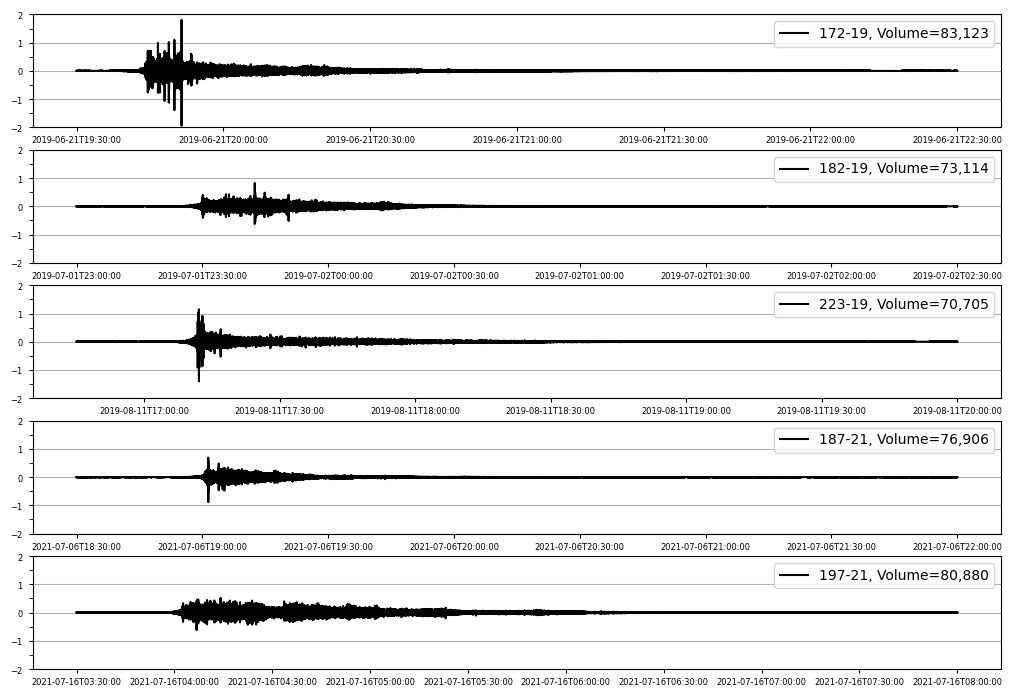

In [80]:
fig, ax = plt.subplots(5, 1, figsize=(12.5,8.5), sharey=True)

ax[0].plot(st1[0].times('matplotlib'), st1[0].data, color="k", alpha=1, label="172-19, Volume=83,123")
ax[1].plot(st2[0].times('matplotlib'), st2[0].data, color="k", alpha=1, label="182-19, Volume=73,114")
ax[2].plot(st3[0].times('matplotlib'), st3[0].data, color="k", alpha=1, label="223-19, Volume=70,705")
ax[3].plot(st4[0].times('matplotlib'), st4[0].data, color="k", alpha=1, label="187-21, Volume=76,906")
ax[4].plot(st5[0].times('matplotlib'), st5[0].data, color="k", alpha=1, label="197-21, Volume=80,880")


for axis in ax:
    axis.xaxis_date()
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%dT%H:%M:%S'))
    axis.set_ylim(-2, 2)
    axis.grid(axis="y")
    axis.legend(loc='upper right')

for axis in ax:
    axis.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    axis.yaxis.set_major_locator(MultipleLocator(1))
    axis.yaxis.set_minor_locator(MultipleLocator(0.5))
    axis.tick_params(axis='both', which='major', labelsize=6, length=3)
    axis.tick_params(axis='y', which='minor', labelsize=6, length=3)

#### 187-21 vs 197-21

In [ ]:
st4[0].times('UTCDateTime')[0]

array([0.000000e+00, 1.000000e-02, 2.000000e-02, ..., 1.259998e+04,
       1.259999e+04, 1.260000e+04])

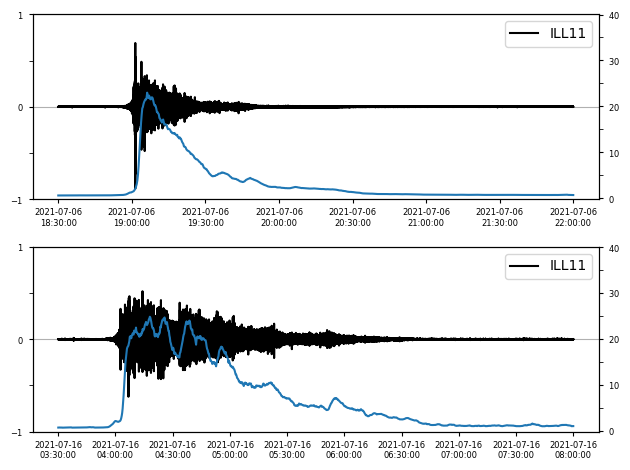

In [95]:
fig, ax = plt.subplots(2, 1)

ax[0].plot(st4[0].times('matplotlib'), st4[0].data, color="k", label="ILL11")
ax_t = ax[0].twinx()
df = pd.read_csv("../model_test/ILL11/xLSTM_15/2021/df/187.csv")
df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
df = df[df['Timestamps'].between(st4[0].times('UTCDateTime')[0], st4[0].times('UTCDateTime')[-1])]
times = df['Timestamps'].apply(lambda x: UTCDateTime(x).matplotlib_date)
ax_t.plot(times, df['Predicted_Output_Mean'].to_numpy())
ax_t.set_ylim(-0.2, 40);
ax_t.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax_t.yaxis.set_major_locator(MultipleLocator(10))
ax_t.yaxis.set_minor_locator(MultipleLocator(5))
ax_t.tick_params(axis='y', which='major', labelsize=6, length=3)
ax_t.tick_params(axis='y', which='minor', labelsize=6, length=3)
ax[1].plot(st5[0].times('matplotlib'), st5[0].data, color="k", label="ILL11")
ax_t = ax[1].twinx()
df = pd.read_csv("../model_test/ILL11/xLSTM_15/2021/df/197.csv")
df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
df = df[df['Timestamps'].between(st5[0].times('UTCDateTime')[0], st5[0].times('UTCDateTime')[-1])]
times = df['Timestamps'].apply(lambda x: UTCDateTime(x).matplotlib_date)
ax_t.plot(times, df['Predicted_Output_Mean'].to_numpy())
ax_t.set_ylim(-0.2, 40);
ax_t.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax_t.yaxis.set_major_locator(MultipleLocator(10))
ax_t.yaxis.set_minor_locator(MultipleLocator(5))
ax_t.tick_params(axis='y', which='major', labelsize=6, length=3)
ax_t.tick_params(axis='y', which='minor', labelsize=6, length=3)

for axis in ax:
    axis.xaxis_date()
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M:%S'))
    axis.set_ylim(-1, 1)
    axis.grid(axis="y")
    axis.legend(loc='upper right')

for axis in ax:
    axis.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    axis.yaxis.set_major_locator(MultipleLocator(1))
    axis.yaxis.set_minor_locator(MultipleLocator(0.5))
    axis.tick_params(axis='both', which='major', labelsize=6, length=3)
    axis.tick_params(axis='y', which='minor', labelsize=6, length=3)

fig.tight_layout()
fig.savefig("./output_images4/187-197-15sec.png", dpi=600)

In [7]:
df_cha = pd.read_csv("../label/DF_Characteristics_2019-2023.csv", index_col=0)
df_cha = df_cha[df_cha['Volume'].notna()]

In [8]:
df_cha.describe()

,Year,Julday,Volume,Velocity,Duration,Density
count,41.000000,41.000000,41.000000,41.000000,34.000000,41.000000
mean,2020.756098,186.878049,44532.219512,3.592683,49.970588,1702.658537
std,1.374418,46.271047,55933.383370,3.317580,27.762505,286.307406
min,2019.000000,118.000000,1362.000000,0.490000,15.000000,987.000000
25%,2020.000000,156.000000,6175.000000,1.500000,29.500000,1568.000000
50%,2021.000000,181.000000,20951.000000,2.320000,42.500000,1685.000000
75%,2022.000000,207.000000,76906.000000,3.970000,55.750000,1862.000000
max,2023.000000,318.000000,301099.000000,15.460000,121.000000,2323.000000


In [9]:
# group1 = df_cha[((df_cha['Year'] == 2021) & ((df_cha['Julday'] == 175) | (df_cha['Julday'] == 187) | (df_cha['Julday'] == 194) | (df_cha['Julday'] == 156))) | 
#        ((df_cha['Year'] == 2022) & (df_cha['Julday'] == 185)) | 
#        ((df_cha['Year'] == 2023) & (df_cha['Julday'] == 193))]
group1 = df_cha[((df_cha['Year'] == 2021) & ((df_cha['Julday'] == 175) | (df_cha['Julday'] == 187) | (df_cha['Julday'] == 194))) | 
       ((df_cha['Year'] == 2022) & (df_cha['Julday'] == 185)) | 
       ((df_cha['Year'] == 2023) & (df_cha['Julday'] == 193))]
group1

,Event_Date,Year,Julday,Volume,Velocity,Duration,Density
24,2021-06-24,2021,175,114424.0,8.18,38.0,1628
25,2021-07-06,2021,187,76906.0,8.69,28.0,1605
27,2021-07-13,2021,194,50861.0,2.84,97.0,1373
33,2022-07-04,2022,185,115963.0,8.18,68.0,1140
39,2023-07-12,2023,193,119088.0,15.46,NaN,1785


In [10]:
# group2 = df_cha[((df_cha['Year'] == 2021) & ((df_cha['Julday'] == 173) | (df_cha['Julday'] == 197) | (df_cha['Julday'] == 219) | (df_cha['Julday'] == 262))) | 
#        ((df_cha['Year'] == 2020) & ((df_cha['Julday'] == 160) | (df_cha['Julday'] == 169) | (df_cha['Julday'] == 181))) | 
#        ((df_cha['Year'] == 2023) & ((df_cha['Julday'] == 153) | (df_cha['Julday'] == 161)))]
group2 = df_cha[((df_cha['Year'] == 2021) & ((df_cha['Julday'] == 197) | (df_cha['Julday'] == 219))) | 
       ((df_cha['Year'] == 2023) & ((df_cha['Julday'] == 153) | (df_cha['Julday'] == 161)))]
group2

,Event_Date,Year,Julday,Volume,Velocity,Duration,Density
28,2021-07-16,2021,197,80880.0,2.78,77.0,1916
29,2021-08-07,2021,219,38737.0,2.32,46.0,1884
37,2023-06-02,2023,153,4873.0,1.73,NaN,1724
38,2023-06-10,2023,161,18534.0,2.02,NaN,1787


In [11]:
group1.describe().loc[['mean', 'std'], ['Velocity', 'Density', 'Duration']]

,Velocity,Density,Duration
mean,8.67000,1506.200000,57.750000
std,4.48814,252.076774,31.202297


In [12]:
group2.describe().loc[['mean', 'std'], ['Velocity', 'Density', 'Duration']]

,Velocity,Density,Duration
mean,2.212500,1827.750000,61.50000
std,0.448507,88.273722,21.92031


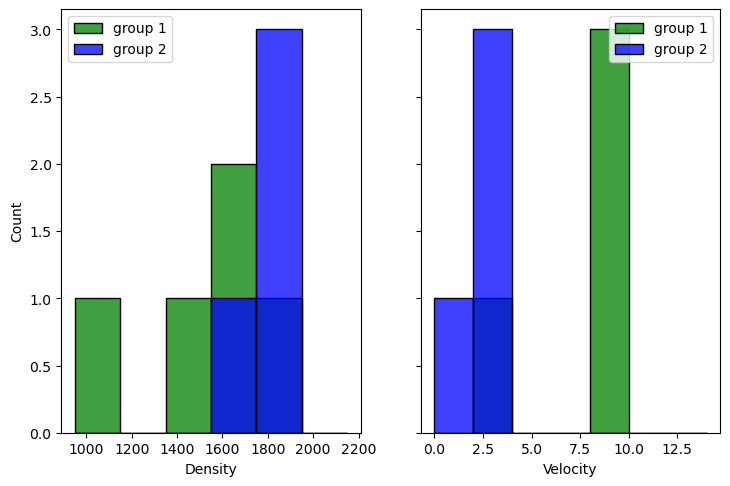

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(8.5, 5.5), sharey=True)

sns.histplot(data=group1, x="Density", kde=False, ax=ax[0], bins = np.arange(950, 2350, 200), label="group 1", color="g")
sns.histplot(data=group2, x="Density", kde=False, ax=ax[0], bins = np.arange(950, 2350, 200), label="group 2", color="b")

sns.histplot(data=group1, x="Velocity", kde=False, ax=ax[1], bins = np.arange(0, 16, 2), label="group 1", color="g")
sns.histplot(data=group2, x="Velocity", kde=False, ax=ax[1], bins = np.arange(0, 16, 2), label="group 2", color="b")

for axis in ax:
    axis.legend(loc="best")

In [14]:
np.arange(950, 2350, 150)

array([ 950, 1100, 1250, 1400, 1550, 1700, 1850, 2000, 2150, 2300])

## 175-21, 185-22, 193-23

In [38]:
st10 = load_seismic_data_test(175, "ILL11", 2021, freq=15)
# st10.trim(starttime=UTCDateTime(start_times_2021[5]), endtime=UTCDateTime(end_times_2021[5]))
st11 = load_seismic_data_test(175, "ILL11", 2021, freq=45)
# st11.trim(starttime=UTCDateTime(start_times_2021[5]), endtime=UTCDateTime(end_times_2021[5]))

st20 = load_seismic_data_test(185, "ILL11", 2022, freq=15)
# st20.trim(starttime=UTCDateTime(start_times_2022[1]), endtime=UTCDateTime(end_times_2022[1]))
st21 = load_seismic_data_test(185, "ILL11", 2022, freq=45)
# st21.trim(starttime=UTCDateTime(start_times_2022[1]), endtime=UTCDateTime(end_times_2022[1]))

st30 = load_seismic_data_test(193, "ILL11", 2023, freq=15)
# st30.trim(starttime=UTCDateTime(start_times_2023[2]), endtime=UTCDateTime(end_times_2023[2]))
st31 = load_seismic_data_test(193, "ILL11", 2023, freq=45)
# st31.trim(starttime=UTCDateTime(start_times_2023[2]), endtime=UTCDateTime(end_times_2023[2]))

st40 = load_seismic_data_test(232, "ILL11", 2019, freq=15)
# st40.trim(starttime=UTCDateTime(event_id_map["9"]['start_time']), endtime=UTCDateTime(event_id_map["9"]['end_time']))
st41 = load_seismic_data_test(232, "ILL11", 2019, freq=45)
# st41.trim(starttime=UTCDateTime(event_id_map["9"]['start_time']), endtime=UTCDateTime(event_id_map["9"]['end_time']))


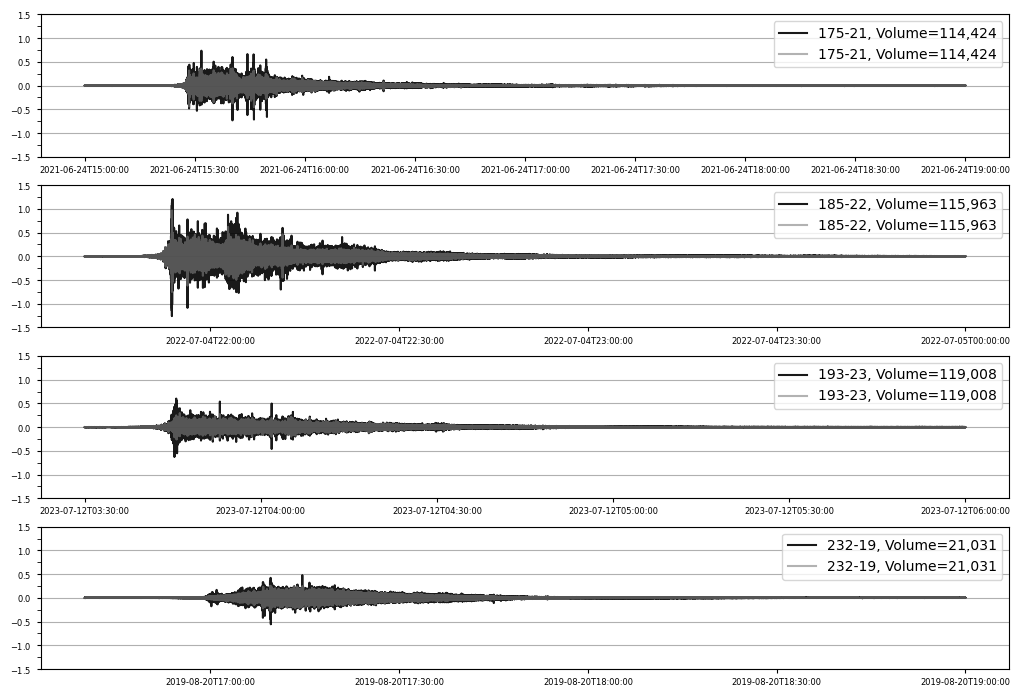

In [10]:
fig, ax = plt.subplots(4, 1, figsize=(12.5,8.5), sharey=True)

ax[0].plot(st11[0].times('matplotlib'), st11[0].data, color="k", alpha=0.9, label="175-21, Volume=114,424")
ax[1].plot(st21[0].times('matplotlib'), st21[0].data, color="k", alpha=0.9, label="185-22, Volume=115,963")
ax[2].plot(st31[0].times('matplotlib'), st31[0].data, color="k", alpha=0.9, label="193-23, Volume=119,008")
ax[3].plot(st41[0].times('matplotlib'), st41[0].data, color="k", alpha=0.9, label="232-19, Volume=21,031")

ax[0].plot(st10[0].times('matplotlib'), st10[0].data, color="grey", alpha=0.6, label="175-21, Volume=114,424")
ax[1].plot(st20[0].times('matplotlib'), st20[0].data, color="grey", alpha=0.6, label="185-22, Volume=115,963")
ax[2].plot(st30[0].times('matplotlib'), st30[0].data, color="grey", alpha=0.6, label="193-23, Volume=119,008")
ax[3].plot(st40[0].times('matplotlib'), st40[0].data, color="grey", alpha=0.6, label="232-19, Volume=21,031")


for axis in ax:
    axis.xaxis_date()
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%dT%H:%M:%S'))
    axis.set_ylim(-1.5,1.5)
    axis.grid(axis="y")
    axis.legend(loc='upper right')

for axis in ax:
    axis.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    axis.yaxis.set_major_locator(MultipleLocator(0.5))
    axis.yaxis.set_minor_locator(MultipleLocator(0.25))
    axis.tick_params(axis='both', which='major', labelsize=6, length=3)
    axis.tick_params(axis='y', which='minor', labelsize=6, length=3)

# Looking into ES

In [15]:
import pytz
from datetime import datetime, timedelta, timezone

import numpy as np
import warnings
from obspy import Stream, Trace

from scipy.signal import hilbert, lfilter, butter, spectrogram
from scipy.stats import kurtosis, skew, iqr


def stream_to_trace(st):

    if isinstance(st, Stream):

        if len(st) == 0:
            raise ValueError("Stream is empty, cannot convert to Trace")
        elif len(st) > 1:
            warnings.warn(f"Stream contains {len(st)} traces, returning only the first one")
            tr = st[0]
        else:
            tr = st[0]

    elif isinstance(st, Trace):
        tr = st

    else:
        raise TypeError(f"Expected Stream or Trace, got {type(st).__name__}")

    return tr

def chunk_data(data, data_start_time, data_sps, window_size, window_overlap):
    '''
    Chunk the data into chunks of size window_size

    Args:
        data: 1D data-array,
        data_start_time: str, format as "%Y-%m-%dT%H:%M:%S"
        data_sps: int or float, data sampling rate
        window_size: int, unit by second,
        window_overlap: float, overlap between windows

    Returns:
        t_value: 1D array-like time stamps
        t_str: 1D array-like time str
        chunk_x: 1D array-like chunk data
    '''
    x_seq_length = int(data_sps * window_size)  # samples per window
    step = int(x_seq_length * (1 - window_overlap))  # step size

    n_windows = (len(data) - x_seq_length) // step + 1
    last_idx = n_windows * step + x_seq_length - step

    # warn if last window is too short
    if last_idx < len(data):
        warnings.warn(f"\nLast window is smaller than window_size. \n"
                      f"data size in last window: {len(data) - n_windows * step}\n"
                      f"data size in normal window:  {x_seq_length}")

    # use stride_tricks to generate overlapping windows
    shape = (n_windows, x_seq_length)
    strides = (data.strides[0] * step, data.strides[0])
    chunk_x = np.lib.stride_tricks.as_strided(data[:last_idx], shape=shape, strides=strides)

    # generate timestamps
    date_start_time = datetime.strptime(data_start_time, "%Y-%m-%dT%H:%M:%S")
    timestamps = np.array([date_start_time + timedelta(seconds=i / data_sps) for i in range(len(data))])
    timestamps = np.array([(ts - datetime(1970, 1, 1)).total_seconds() for ts in timestamps])

    # the start time of the segement
    t_value = timestamps[::step][:n_windows]
    t_str = [datetime.fromtimestamp(ts, tz=timezone.utc).isoformat() for ts in t_value]

    return t_value, t_str, chunk_x

def get_freq_band_energy(data,
                         sps,
                         freq_lower=(1, 5, 15, 25, 35),
                         freq_upper=(5, 15, 25, 35, 45)):

    '''
    Calculate log10 energy in multiple frequency bands using bandpass filtering + Hilbert transform.

    Args:
        data: array-like, 1D seismic waveform.
        sps: float, data sampling rate (samples per second).
        freq_lower: tuple, frequency band edges
        freq_upper: tuple, frequency band edges

    Returns:

    '''

    # convert to array
    data = np.asarray(data, dtype=float)

    if len(freq_lower) != len(freq_upper):
        raise ValueError(f"freq_lower = {freq_lower} and "
                         f"freq_upper = {freq_upper} must have same length.")

    nf = len(freq_lower)
    seismic_energy = np.empty(nf, dtype=float)

    Nyquist = sps / 2

    for i, (f_low, f_high) in enumerate(zip(freq_lower, freq_upper)):

        # Normalize to Nyquist
        wn = [f_low / Nyquist, f_high / Nyquist]
        # Butterworth bandpass filter
        b, a = butter(N=2, Wn=wn, btype='band')
        # Filter data
        data_filt = lfilter(b, a, data)

        # Hilbert envelope energy (trapz integral)
        analytic_signal = hilbert(data_filt)
        envelope = np.abs(analytic_signal)

        seismic_energy[i] = np.log10(np.trapz(envelope))

    return seismic_energy


def single_day_ES(st, window_size, window_overlap,
                  freq_lower=(1, 5, 15, 25, 35),
                  freq_upper=(5, 15, 25, 35, 45)):

    tr = stream_to_trace(st=st)
    data = tr.data
    data_start_time = tr.stats.starttime.strftime("%Y-%m-%dT%H:%M:%S")
    data_sps = tr.stats.sampling_rate

    # chunk the data to avoid the loop-st.trim
    t_value, t_str, chunk_x = chunk_data(data, data_start_time, data_sps, window_size, window_overlap)
    print(len(t_str), len(data))
    # prepare the empty temp_ES to store the results
    temp_ES = np.empty((len(t_str), len(freq_lower)), dtype=float)
    for i in tqdm(range(len(t_str)), file=sys.stdout):
        data_temp = chunk_x[i]

        es_arr = get_freq_band_energy(data_temp, data_sps,
                                      freq_lower=freq_lower,
                                      freq_upper=freq_upper)
        temp_ES[i] = es_arr

    # save the npy file
    output_path = f"./ES_output/seis_energy"
    os.makedirs(output_path, exist_ok=True)
    output_name = f"{tr.stats.network}.{tr.stats.station}.{tr.stats.channel}.{tr.stats.starttime.year}.{tr.stats.starttime.julday:03d}"
    np.savez(f"{output_path}/{output_name}.npz",
             allow_pickle=True,
             t_str=t_str,
             t_float=t_value,
             seismic_energy=temp_ES)

In [47]:
single_day_ES(st31, window_size=15, window_overlap=0, freq_lower=(1, 5, 15, 35), freq_upper=(5, 15, 35, 45))

/var/folders/9b/f10dy2654w79wqw49pdgt37c0000gp/T/ipykernel_18919/231575565.py:56: UserWarning: 
Last window is smaller than window_size. 
data size in last window: 1
data size in normal window:  1500
  warnings.warn(f"\nLast window is smaller than window_size. \n"


5760 8640001
100%|██████████| 5760/5760 [00:12<00:00, 478.21it/s]


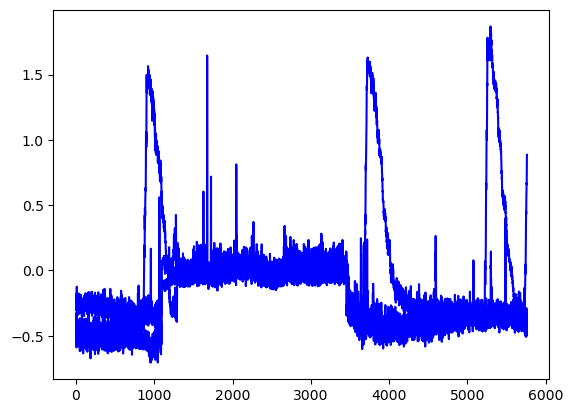

In [48]:
for file in os.listdir("./ES_output/seis_energy/"):
    arr = np.load(f"./ES_output/seis_energy/{file}")
    plt.plot(arr['seismic_energy'][:,0], color="b")
    # plt.plot(arr['seismic_energy'][:,1], color="r")
    # plt.plot(arr['seismic_energy'][:,2], color="g")